# ATLAS-FN 01 — Data Preparation FINAL v3: BMC Table 1 exact + complete prepared workspace

This notebook prepares the HC18/Confirm source workspace, reconciles raw Colab spacing provenance against the BMC manuscript Table 1 lock, and materialises both root-level datasets and `data/prepared/*` datasets before export.


## Section map: explicit legacy replication

| This notebook section | Replicates legacy notebook behaviour | Key implementation |
|---|---|---|
| 1. Setup | DockerRoot Cell 1 / 1.1 | local workspace, reproducibility controls, non-blocking audit logger |
| 2. Zenodo acquisition + deep extraction | DockerRoot Cell 2 / 2.1 | download Zenodo 8265464, extract every top-level and nested archive independently, preserve restart safety |
| 2B. File-tree scout | DockerRoot Cell 3.0 | print image-rich folder tree for manual inspection |
| 3. Strict root resolution + detective surveyor | DockerRoot Cell 3A+ | exact `FOLDER_MAP`, but with Colab-safe root resolver; COCO brain/head; YOLO `obj_train_data` structure labels with `1=CSP`, `2=LV`; no stale symlink dependence |
| 3B. Source visual audit | DockerRoot Cell 3B | random brain/CSP/LV overlays before split/materialisation |
| 4. Split and materialisation | legacy physical datasets audited in DockerRoot Cell 3.X | patient-exclusive `dataset_brain` and `dataset_structures` with denominator checks |
| 4B. Post-split visual audit | DockerRoot Cell 3.X | random physical-dataset overlays after split/materialisation |
| 5. ROI enhanced dataset | DockerRoot GrandMaster data engine | brain crop + 25 px padding + CLAHE + remapped CSP/LV labels |
| 6. Full integrity audit | DockerRoot Cell 3.X + manuscript denominator audit | leakage, disk counts, source dedupe, visual artefacts, expected-count comparison |

**v6 correction.** The previous versions tried to force Colab into the DockerRoot folder layout through aliases/symlinks. That was fragile and could leave stale aliases across reruns. v6 resolves the actual raw-image and label roots first, audits them, and the surveyor consumes that resolved map directly. The primary survey uses DockerRoot semantics, but avoids accidental use of image-only folders or `ImageSets` text files as YOLO labels.


In [1]:
# =============================================================================
# 1. SETUP AND GLOBAL CONTROLS
# =============================================================================
import os, sys, json, math, random, shutil, zipfile, tarfile, hashlib, subprocess
from pathlib import Path
from collections import defaultdict, Counter
from datetime import datetime, timezone
from typing import Dict, List, Optional, Tuple, Sequence, Any

try:
    import pandas as pd
    import numpy as np
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pandas', 'numpy'])
    import pandas as pd
    import numpy as np

try:
    import cv2
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'opencv-python-headless'])
    import cv2

try:
    import requests
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'requests'])
    import requests

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

# ----------------------------
# Runtime controls
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# In Colab use local NVMe (/content); in DockerRoot this can be changed to /workspace.
WORKSPACE = Path(os.environ.get('ATLAS_WORKSPACE', '/content/atlas_fn_workspace'))
SOURCE_ROOT = WORKSPACE / 'fast_local_cache' / 'Zenodo_ALZ'
OUTPUT_ROOT = WORKSPACE / 'outputs' / 'data_prep_integrity'
TRAINING_RUNS_DIR = WORKSPACE / 'Training_Runs'
STRUCT_DIR = WORKSPACE / 'dataset_structures'
BRAIN_DIR = WORKSPACE / 'dataset_brain'
ROI_DIR = WORKSPACE / 'dataset_roi_enhanced_gt'
VALID_JSON = TRAINING_RUNS_DIR / 'valid_real_images.json'
INVENTORY_OUT = STRUCT_DIR / 'clinical_inventory_master.json'

ALLOW_NETWORK_DOWNLOADS = True
FORCE_REDOWNLOAD = False
FORCE_REEXTRACT = False
FORCE_REPREPARE = True
USE_HARDLINKS = True
USE_SYMLINKS = False
COPY_FALLBACK = True
DELETE_NESTED_ZIPS_AFTER_EXTRACT = False  # DockerRoot deleted nested zips; Colab keeps them for restart safety.
STOP_ON_CRITICAL = False                  # Integrity notebook should report, not interrupt long runs.
VISUAL_AUDIT_SAMPLES = 6                    # DockerRoot-style random manual overlay samples.
ALLOW_GLOBAL_YOLO_INDEX_FALLBACK = False # Keep the primary survey DockerRoot-exact; diagnostics compute global counts separately.

IMAGE_EXTS = {'.png', '.jpg', '.jpeg'}
SOURCE_ZENODO_RECORD = '8265464'
SOURCE_ZENODO_DOI = '10.5281/zenodo.8265464'
SOURCE_FILE_ALLOWLIST = [
    'Diverse Fetal Head Images.zip',
    'Trans-thalamic.zip',
    'Trans-ventricular.zip',
    'Trans-cerebellum.zip',
    'Readme.txt',
]

# Exact DockerRoot Cell 3A+ folder map.
FOLDER_MAP = {
    'Trans-Cerebellar':  {'raw': 'Trans-cerebellum-orginal-size', 'root': 'Trans-cerebellum'},
    'Trans-Thalamic':    {'raw': 'Trans-thalamic-orginal-size', 'root': 'Trans-thalamic'},
    'Trans-Ventricular': {'raw': 'Trans-ventricular-orginal-size', 'root': 'Trans-ventricular'},
    'Diverse':           {'raw': 'Diverse Fetal Head Images-orginal-image', 'root': 'Diverse Fetal Head Images'},
}

EXPECTED_DOCKERROOT_SURVEY = {
    'valid_images': 3948,
    'brain': 3790,      # DockerRoot printed target 3,794 but found 3,790 and accepted OK.
    'brain_target_label': 3794,
    'csp': 1864,
    'lv': 1512,
    'complete_pairs': 2259,
}

EXPECTED_DOCKERROOT_DISK = {
    'train': {'images': 2629, 'brain': 2629, 'csp': 1306, 'lv': 1076},
    'val':   {'images': 575,  'brain': 575,  'csp': 271,  'lv': 224},
    'test':  {'images': 586,  'brain': 586,  'csp': 287,  'lv': 212},
}
EXPECTED_MANUSCRIPT_SPLIT = {
    'train': {'patients': 1290, 'frames': 2629},
    'val':   {'patients': 271,  'frames': 575},
    'test':  {'patients': 279,  'frames': 586},
}

PIXEL_SPACING_FALLBACK_MM_PER_PX = 0.125
PIXEL_SPACING_RANGE = (0.04, 0.40)
ROI_PAD_PX = 25
ROI_CLAHE_CLIP_LIMIT = 2.0
ROI_CLAHE_TILE_GRID = (8, 8)

for p in [WORKSPACE, SOURCE_ROOT, OUTPUT_ROOT/'logs', OUTPUT_ROOT/'tables', OUTPUT_ROOT/'manifests', TRAINING_RUNS_DIR, STRUCT_DIR, BRAIN_DIR, ROI_DIR]:
    p.mkdir(parents=True, exist_ok=True)

ISSUES, CHECKS = [], []

def now_iso():
    return datetime.now(timezone.utc).isoformat()

def to_jsonable(x):
    if isinstance(x, Path): return str(x)
    if isinstance(x, (np.integer,)): return int(x)
    if isinstance(x, (np.floating,)): return float(x)
    if isinstance(x, (set, tuple)): return list(x)
    if isinstance(x, dict): return {str(k): to_jsonable(v) for k,v in x.items()}
    if isinstance(x, list): return [to_jsonable(v) for v in x]
    return x

def record_issue(layer: str, message: str, severity: str = 'warning', **kwargs):
    row = {'ts': now_iso(), 'layer': layer, 'severity': severity, 'message': message, **{k: to_jsonable(v) for k,v in kwargs.items()}}
    ISSUES.append(row)
    print(f"[{severity}:{layer}] {message}" + (f" | {kwargs}" if kwargs else ""))
    if severity == 'critical' and STOP_ON_CRITICAL:
        raise RuntimeError(f"Critical issue: {layer}: {message}")
    return row

def record_check(layer: str, check: str, passed: bool, observed=None, expected=None, severity: str = 'warning', detail: str = ''):
    row = {'ts': now_iso(), 'layer': layer, 'check': check, 'passed': bool(passed), 'observed': to_jsonable(observed), 'expected': to_jsonable(expected), 'severity': severity, 'detail': detail}
    CHECKS.append(row)
    symbol = '✓' if passed else '✗'
    print(f"[{layer}] {symbol} {check}: {'PASS' if passed else 'FLAG'}")
    if (not passed) and severity == 'critical' and STOP_ON_CRITICAL:
        raise RuntimeError(f"Integrity check failed: {layer}:{check}\nObserved={observed}\nExpected={expected}\n{detail}")
    return passed

def normalise_name(s: str) -> str:
    return ''.join(ch.lower() for ch in str(s) if ch.isalnum())

def iter_progress(iterable, **kwargs):
    return tqdm(iterable, **kwargs) if tqdm else iterable

def sha1_text(s: str) -> str:
    return hashlib.sha1(str(s).encode('utf-8')).hexdigest()

print(f"Workspace: {WORKSPACE}")
print(f"Source root: {SOURCE_ROOT}")


def ensure_alias_dir(src: Path, dst: Path, mode: str = 'symlink') -> Path:
    """Ensure dst exists as an alias to src. Prefer symlink, fall back to copytree."""
    src, dst = Path(src), Path(dst)
    if dst.exists():
        return dst
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        if mode == 'symlink':
            os.symlink(src, dst, target_is_directory=True)
        else:
            shutil.copytree(src, dst)
    except Exception:
        try:
            shutil.copytree(src, dst)
        except Exception as e:
            record_issue('layout', 'Could not create DockerRoot alias directory', severity='critical', src=src, dst=dst, error=repr(e))
    return dst



Workspace: /content/atlas_fn_workspace
Source root: /content/atlas_fn_workspace/fast_local_cache/Zenodo_ALZ


In [2]:
# =============================================================================
# 2. ZENODO ACQUISITION, DEEP EXTRACTION, AND STRICT ROOT RESOLUTION
# =============================================================================

# Replication principle:
# DockerRoot Cell 3A+ assumes a direct-child layout under CONFIG["CACHE_DIR"].
# In Colab/Zenodo, the same semantic roots can be nested differently and prior
# reruns may leave stale aliases. v6 therefore does NOT trust existing aliases.
# It resolves the actual image and label roots by content, writes an audit table,
# and passes that resolved map directly to the Cell 3A+ surveyor.


def zenodo_catalog(record: str) -> Tuple[dict, dict]:
    url = f'https://zenodo.org/api/records/{record}'
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    meta = r.json()
    files = {}
    for f in meta.get('files', []):
        key = f.get('key') or f.get('filename')
        links = f.get('links') or {}
        files[key] = {
            'url': links.get('self') or links.get('download'),
            'size': f.get('size'),
            'checksum': f.get('checksum'),
        }
    return meta, files


def download_stream(url: str, dst: Path, force: bool = False) -> Optional[Path]:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0 and not force:
        print(f"[download] reuse {dst.name} size_mb={dst.stat().st_size/1e6:.1f}")
        return dst
    if not ALLOW_NETWORK_DOWNLOADS:
        record_issue('download', 'Network disabled and file missing', severity='critical', dst=dst)
        return None
    try:
        with requests.get(url, stream=True, timeout=240) as r:
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            bar = tqdm(total=total, unit='B', unit_scale=True, desc=dst.name) if tqdm else None
            with open(dst, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    if chunk:
                        f.write(chunk)
                        if bar:
                            bar.update(len(chunk))
            if bar:
                bar.close()
        return dst
    except Exception as e:
        record_issue('download', 'Download failed', severity='critical', url=url, dst=dst, error=repr(e))
        return None


def archive_marker(zip_path: Path, target_dir: Path, prefix: str = 'extract') -> Path:
    key = sha1_text(str(zip_path.resolve()) + '|' + str(zip_path.stat().st_size if zip_path.exists() else 0))[:12]
    safe = ''.join(ch if ch.isalnum() or ch in '._-' else '_' for ch in zip_path.stem)[:80]
    return target_dir / f'.{prefix}_{safe}_{key}.complete'


def extract_zip_to_target(zip_path: Path, out_dir: Path, force: bool = False, prefix: str = 'extract') -> bool:
    if not zip_path.exists() or zip_path.stat().st_size == 0:
        record_issue('extract', 'Zip missing or empty', severity='critical', archive=zip_path)
        return False
    marker = archive_marker(zip_path, out_dir, prefix=prefix)
    if marker.exists() and not force:
        return False
    out_dir.mkdir(parents=True, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(out_dir)
        marker.write_text(json.dumps({'archive': str(zip_path), 'target': str(out_dir), 'ts': now_iso()}, indent=2))
        return True
    except Exception as e:
        record_issue('extract', 'Zip extraction failed', severity='critical', archive=zip_path, target=out_dir, error=repr(e))
        return False


def acquire_source() -> Path:
    SOURCE_ROOT.mkdir(parents=True, exist_ok=True)
    manifest_path = SOURCE_ROOT / 'zenodo_manifest.json'
    manifest = {'record': SOURCE_ZENODO_RECORD, 'doi': None, 'title': None, 'files': {}}
    try:
        meta, files = zenodo_catalog(SOURCE_ZENODO_RECORD)
        manifest.update({'doi': meta.get('doi'), 'title': (meta.get('metadata') or {}).get('title')})
        for fname in SOURCE_FILE_ALLOWLIST:
            if fname not in files:
                record_issue('zenodo', 'Expected file missing from Zenodo record', severity='critical', file=fname)
                continue
            dst = SOURCE_ROOT / fname
            download_stream(files[fname]['url'], dst, force=FORCE_REDOWNLOAD)
            manifest['files'][fname] = {'path': str(dst), **files[fname]}
            if dst.suffix.lower() == '.zip' and dst.exists() and dst.stat().st_size > 0:
                did = extract_zip_to_target(dst, SOURCE_ROOT, force=FORCE_REEXTRACT, prefix='top')
                print(f"[extract] top-level archive {'extracted' if did else 'already extracted'} | archive={dst.name}, target={SOURCE_ROOT}")
        manifest_path.write_text(json.dumps(manifest, indent=2))
        print(f"[zenodo] manifest written: {manifest_path}")
    except Exception as e:
        record_issue('zenodo', 'Could not open/download Zenodo record', severity='critical', error=repr(e))
        manifest_path.write_text(json.dumps(manifest, indent=2))
    return SOURCE_ROOT


def deep_extract_all_nested_zips(root: Path, max_rounds: int = 8):
    audit = []
    for round_idx in range(1, max_rounds + 1):
        zips = []
        for z in sorted(root.rglob('*.zip')):
            if z.parent == root and z.name in SOURCE_FILE_ALLOWLIST:
                continue
            marker = archive_marker(z, z.parent, prefix='nested')
            if marker.exists() and not FORCE_REEXTRACT:
                continue
            zips.append(z)
        if not zips:
            print(f"[extract] nested DockerRoot extraction complete after round {round_idx-1}")
            break
        print(f"[extract] round {round_idx}: extracting {len(zips)} nested zip(s) into parent folders")
        for z in iter_progress(zips, desc=f'extract nested r{round_idx}'):
            did = extract_zip_to_target(z, z.parent, force=FORCE_REEXTRACT, prefix='nested')
            if did:
                audit.append({'round': round_idx, 'archive': str(z.relative_to(root)), 'target': str(z.parent.relative_to(root))})
                if DELETE_NESTED_ZIPS_AFTER_EXTRACT:
                    z.unlink(missing_ok=True)
    (OUTPUT_ROOT/'logs'/'nested_deep_extraction_audit.json').write_text(json.dumps(audit, indent=2))
    print(f"[extract] nested extraction audit entries={len(audit)}")
    return audit


def image_files_under(p: Optional[Path]) -> List[Path]:
    if not p or not p.exists():
        return []
    return [x for x in p.rglob('*') if x.is_file() and x.suffix.lower() in IMAGE_EXTS]


def image_count(p: Optional[Path]) -> int:
    return len(image_files_under(p))


def txt_files_under(p: Optional[Path]) -> List[Path]:
    if not p or not p.exists():
        return []
    return [x for x in p.rglob('*.txt') if x.is_file() and 'readme' not in x.name.lower()]


def txt_count(p: Optional[Path]) -> int:
    return len(txt_files_under(p))


def json_files_under(p: Optional[Path]) -> List[Path]:
    if not p or not p.exists():
        return []
    return [x for x in p.rglob('*.json') if x.is_file()]


def json_count(p: Optional[Path]) -> int:
    return len(json_files_under(p))


def safe_relative(p: Optional[Path], root: Path = SOURCE_ROOT) -> str:
    if not p:
        return ''
    try:
        return str(Path(p).relative_to(root))
    except Exception:
        return str(p)


def leaf_image_dirs(root: Path) -> List[Path]:
    """Return image-bearing directories, preferring leaf directories to wrappers."""
    candidates = []
    for p in root.rglob('*'):
        if not p.is_dir():
            continue
        direct = [x for x in p.iterdir() if x.is_file() and x.suffix.lower() in IMAGE_EXTS]
        if direct:
            candidates.append(p)
    return candidates


def contains_token(path: Path, tokens: Sequence[str]) -> bool:
    s = normalise_name(str(path))
    return any(normalise_name(t) in s for t in tokens)


def choose_raw_root_for_plane(root: Path, plane: str, expected_name: str, target_n: int, label_root_name: str) -> Optional[Path]:
    """Resolve the raw/original image directory used by DockerRoot Cell 3A+.

    Primary preference is the exact DockerRoot top-level original-size directory. If the
    Zenodo extraction does not expose it, use the best plane-specific image leaf. We avoid
    broad wrapper folders such as `Trans-thalamic/`, because they include masks and training
    artefacts and cause inflated scanning.
    """
    candidates: List[Tuple[tuple, Path]] = []

    exact = root / expected_name
    if exact.exists() and image_count(exact) > 0:
        candidates.append(((0, abs(image_count(exact)-target_n), -image_count(exact), 0, len(str(exact))), exact))

    # Descendant exact-name or spelling variants.
    name_variants = {
        expected_name,
        expected_name.replace('orginal', 'original'),
        expected_name.replace('original', 'orginal'),
    }
    if plane == 'Diverse':
        name_variants.update({'Orginal_train_images_to_959_661', 'Original_train_images_to_959_661'})
    for p in root.rglob('*'):
        if p.is_dir() and p.name in name_variants and image_count(p) > 0:
            candidates.append(((1, abs(image_count(p)-target_n), -image_count(p), 0, len(str(p))), p))

    # Plane-specific image leaf fallback inside the label root, e.g. Trans-thalamic/Trans-thalamic.
    plane_tokens = {
        'Trans-Cerebellar': ['cerebellum', 'cerebellar'],
        'Trans-Thalamic': ['thalamic'],
        'Trans-Ventricular': ['ventricular'],
        'Diverse': ['diverse', 'fetalhead'],
    }.get(plane, [plane])
    for p in leaf_image_dirs(root):
        c = image_count(p)
        if c <= 0:
            continue
        if contains_token(p, plane_tokens):
            # Penalise known derived image/mask/segmentation folders for raw images.
            bad = any(tok in normalise_name(str(p)) for tok in ['mask', 'segmentation', 'gtfine', 'default', 'imagesets'])
            if bad:
                continue
            candidates.append(((2, abs(c-target_n), -c, 1 if p.name != label_root_name else 0, len(str(p))), p))

    if not candidates:
        return None
    candidates = sorted(set((score, p) for score, p in candidates), key=lambda x: x[0])
    return candidates[0][1]


def choose_label_root_for_plane(root: Path, plane: str, expected_name: str) -> Optional[Path]:
    """Resolve the annotation-rich label root for DockerRoot Cell 3A+.

    We deliberately prefer a directory that contains BOTH COCO-style JSON and YOLO
    `obj_train_data` text files. This fixes the v4/v5 failure where image-rich but
    label-poor folders were selected and CSP/LV collapsed to zero.
    """
    candidates: List[Tuple[tuple, Path]] = []
    name_variants = {expected_name}
    for p in root.rglob('*'):
        if not p.is_dir():
            continue
        if p.name not in name_variants:
            continue
        js = json_count(p)
        all_txt = txt_count(p)
        obj_dirs = [q for q in p.rglob('obj_train_data') if q.is_dir()]
        obj_txt = sum(txt_count(q) for q in obj_dirs)
        ann_dirs = [q for q in p.rglob('annotations') if q.is_dir()]
        # Direct child is best when it has evidence; nested duplicate wrappers are acceptable.
        direct_child_penalty = 0 if p.parent == root else 1
        score = (-(js > 0), -(obj_txt > 0), -js, -obj_txt, direct_child_penalty, len(str(p)))
        candidates.append((score, p))

    if not candidates:
        return None
    return sorted(candidates, key=lambda x: x[0])[0][1]


def resolve_dockerroot_plane_roots(root: Path) -> pd.DataFrame:
    target_raw_counts = {
        'Trans-Cerebellar': 714,
        'Trans-Thalamic': 1638,
        'Trans-Ventricular': 597,
        'Diverse': 999,
    }
    rows = []
    for plane, spec in FOLDER_MAP.items():
        raw_root = choose_raw_root_for_plane(root, plane, spec['raw'], target_raw_counts.get(plane, 0), spec['root'])
        label_root = choose_label_root_for_plane(root, plane, spec['root'])
        if raw_root is None:
            record_issue('source', 'Raw/original image root unresolved for plane', plane=plane, expected=spec['raw'])
        if label_root is None:
            record_issue('source', 'Annotation label root unresolved for plane', plane=plane, expected=spec['root'])
        rows.append({
            'plane': plane,
            'raw_expected': spec['raw'],
            'raw_root': str(raw_root) if raw_root else None,
            'raw_images_recursive': image_count(raw_root),
            'raw_images_direct': len([x for x in raw_root.iterdir() if x.is_file() and x.suffix.lower() in IMAGE_EXTS]) if raw_root and raw_root.exists() else 0,
            'label_expected': spec['root'],
            'label_root': str(label_root) if label_root else None,
            'label_json_files': json_count(label_root),
            'label_txt_files_total': txt_count(label_root),
            'label_obj_train_txt_files': sum(txt_count(q) for q in (label_root.rglob('obj_train_data') if label_root else [])),
            'raw_rel': safe_relative(raw_root, root) if raw_root else None,
            'label_rel': safe_relative(label_root, root) if label_root else None,
        })
    df = pd.DataFrame(rows)
    df.to_csv(OUTPUT_ROOT/'tables'/'dockerroot_strict_root_resolution_audit.csv', index=False)
    display(df)
    return df


SOURCE_ROOT = acquire_source()
DEEP_EXTRACT_AUDIT = deep_extract_all_nested_zips(SOURCE_ROOT)
DOCKERROOT_RESOLVED_ROOTS = resolve_dockerroot_plane_roots(SOURCE_ROOT)


Diverse Fetal Head Images.zip:   0%|          | 0.00/313M [00:00<?, ?B/s]

[extract] top-level archive extracted | archive=Diverse Fetal Head Images.zip, target=/content/atlas_fn_workspace/fast_local_cache/Zenodo_ALZ


Trans-thalamic.zip:   0%|          | 0.00/596M [00:00<?, ?B/s]

[extract] top-level archive extracted | archive=Trans-thalamic.zip, target=/content/atlas_fn_workspace/fast_local_cache/Zenodo_ALZ


Trans-ventricular.zip:   0%|          | 0.00/232M [00:00<?, ?B/s]

...

Readme.txt: 0.00B [00:00, ?B/s]

[zenodo] manifest written: /content/atlas_fn_workspace/fast_local_cache/Zenodo_ALZ/zenodo_manifest.json
[extract] round 1: extracting 44 nested zip(s) into parent folders


extract nested r1:   0%|          | 0/44 [00:00<?, ?it/s]

[extract] nested DockerRoot extraction complete after round 1
[extract] nested extraction audit entries=44


,plane,raw_expected,raw_root,raw_images_recursive,raw_images_direct,label_expected,label_root,label_json_files,label_txt_files_total,label_obj_train_txt_files,raw_rel,label_rel
0,Trans-Cerebellar,Trans-cerebellum-orginal-size,/content/atlas_fn_workspace/fast_local_cache/Z...,684,684,Trans-cerebellum,/content/atlas_fn_workspace/fast_local_cache/Z...,3,1373,684,Trans-cerebellum/Trans-cerebellum,Trans-cerebellum
1,Trans-Thalamic,Trans-thalamic-orginal-size,/content/atlas_fn_workspace/fast_local_cache/Z...,1565,1565,Trans-thalamic,/content/atlas_fn_workspace/fast_local_cache/Z...,3,3135,1565,Trans-thalamic/Trans-thalamic,Trans-thalamic
2,Trans-Ventricular,Trans-ventricular-orginal-size,/content/atlas_fn_workspace/fast_local_cache/Z...,584,584,Trans-ventricular,/content/atlas_fn_workspace/fast_local_cache/Z...,3,1173,584,Trans-ventricular/Trans-ventricular,Trans-ventricular
3,Diverse,Diverse Fetal Head Images-orginal-image,/content/atlas_fn_workspace/fast_local_cache/Z...,999,999,Diverse Fetal Head Images,/content/atlas_fn_workspace/fast_local_cache/Z...,3,2003,999,Diverse Fetal Head Images/Orginal_train_images...,Diverse Fetal Head Images


In [3]:
# =============================================================================
# 2B. FILE TREE SCOUT — DOCKERROOT CELL 3.0 STYLE
# =============================================================================

def print_structure(start_path: Path, max_depth: int = 3):
    if not start_path.exists():
        record_issue('scout', 'Source root does not exist', severity='critical', path=start_path)
        return pd.DataFrame()
    print(f"📂 ROOT FOUND: {start_path}")
    rows = []
    for root, dirs, files in os.walk(start_path):
        path = Path(root)
        try:
            depth = len(path.relative_to(start_path).parts)
        except Exception:
            depth = 0
        if depth > max_depth:
            dirs[:] = []
            continue
        png_files = [f for f in files if f.lower().endswith('.png')]
        if png_files:
            rows.append({'path': str(path), 'depth': depth, 'png_files': len(png_files)})
        indent = '   ' * depth
        print(f"{indent}📁 {path.name}/")
        if png_files:
            print(f"{indent}   📷 PNG Images: {len(png_files)} files")
    df = pd.DataFrame(rows)
    df.to_csv(OUTPUT_ROOT/'tables'/'file_tree_png_inventory.csv', index=False)
    return df

FILE_TREE_INVENTORY = print_structure(SOURCE_ROOT, max_depth=3)


📂 ROOT FOUND: /content/atlas_fn_workspace/fast_local_cache/Zenodo_ALZ
📁 Zenodo_ALZ/
   📁 Trans-cerebellum/
      📁 ImageSets/
         📁 Main/
         📁 Segmentation/
      📁 SegmentationClass/
         📷 PNG Images: 684 files
      📁 Trans-cerebellum/
         📷 PNG Images: 684 files
      📁 Annotations/
      📁 annotations/
      📁 masks/
         📁 default/
            📷 PNG Images: 959 files
      📁 obj_train_data/
      📁 default/
         📁 Masks/
            📷 PNG Images: 681 files
      📁 gtFine/
         📁 default/
            📷 PNG Images: 2052 files
      📁 SegmentationObject/
         📷 PNG Images: 684 files
   📁 Trans-thalamic/
      📁 ImageSets/
         📁 Main/
         📁 Segmentation/
      📁 SegmentationClass/
         📷 PNG Images: 1565 files
      📁 Annotations/
      📁 annotations/
      📁 Trans-thalamic/
         📷 PNG Images: 1565 files
      📁 masks/
         📁 default/
            📷 PNG Images: 2531 files
      📁 obj_train_data/
      📁 default/
         📁 Mask

In [4]:
# =============================================================================
# 3. DOCKERROOT-STRICT DETECTIVE SURVEYOR — CELL 3A+ REPLICA
# =============================================================================
#
# This cell is the corrected v6 surveyor. It preserves the legacy logic where it
# matters for scientific reproducibility:
#   - FOLDER_MAP plane names and raw/root concepts are unchanged.
#   - brain/head boxes come from the largest COCO JSON per plane.
#   - CSP/LV boxes come from YOLO TXT labels with raw ID 1=CSP and 2=LV.
#   - valid_real_images.json is generated from resolved raw/original image roots.
#
# It differs from earlier Colab replicas in one important way: it refuses to use
# stale symlink aliases or broad image-wrapper directories. The resolved root table
# from Section 2 is the only source of truth for raw_root and label_root.

CONFIG = {
    'CACHE_DIR': SOURCE_ROOT,
    'VALID_JSON': VALID_JSON,
    'INVENTORY_OUT': INVENTORY_OUT,
}
CONFIG['INVENTORY_OUT'].parent.mkdir(parents=True, exist_ok=True)


def _resolved_row(plane: str) -> Optional[pd.Series]:
    if 'DOCKERROOT_RESOLVED_ROOTS' not in globals() or DOCKERROOT_RESOLVED_ROOTS.empty:
        return None
    sub = DOCKERROOT_RESOLVED_ROOTS[DOCKERROOT_RESOLVED_ROOTS['plane'] == plane]
    return None if sub.empty else sub.iloc[0]


def yolo_txt_candidates(label_root: Path) -> List[Path]:
    """Return YOLO label TXT candidates, preferring DockerRoot `obj_train_data`.

    DockerRoot's broad recursive scan worked in its extracted filesystem. In Colab,
    exported folders also contain ImageSets and other text files. This function keeps
    DockerRoot intent but avoids non-YOLO text files that can overwrite valid labels.
    """
    if not label_root or not Path(label_root).exists():
        return []
    label_root = Path(label_root)
    obj_dirs = [p for p in label_root.rglob('obj_train_data') if p.is_dir()]
    primary = []
    for d in obj_dirs:
        primary.extend([p for p in d.rglob('*.txt') if p.is_file() and 'readme' not in p.name.lower()])
    if primary:
        return sorted(primary)
    # Fallback: still recursive, but exclude known non-label metadata folders.
    out = []
    excluded_parts = {'ImageSets', 'Main', '.ipynb_checkpoints'}
    for p in label_root.rglob('*.txt'):
        if 'readme' in p.name.lower():
            continue
        if any(part in excluded_parts for part in p.parts):
            continue
        out.append(p)
    return sorted(out)


def key_variants_from_stem(stem: str) -> List[str]:
    stem = str(stem)
    base = stem[3:] if stem.startswith('gt_') else stem
    vals = [stem, base, f'gt_{base}']
    # conservative normalised key for occasional extension/path formatting variation
    vals.append(normalise_name(base))
    out, seen = [], set()
    for v in vals:
        if v not in seen:
            out.append(v); seen.add(v)
    return out


def index_all_labels_dockerroot_strict(label_root: Path) -> Tuple[Dict[str, Path], pd.DataFrame, Counter]:
    """Index YOLO structure labels with robust duplicate handling.

    The legacy code used `index[stem] = p`. v6 audits duplicates and chooses the
    `obj_train_data` candidate first so Colab does not accidentally select ImageSets
    or non-YOLO text files. Multiple key variants are registered to reproduce the
    legacy `stem` and `gt_stem` lookup.
    """
    index: Dict[str, Path] = {}
    rank_by_key: Dict[str, tuple] = {}
    rows = []
    raw_ids = Counter()
    for p in yolo_txt_candidates(label_root):
        ids = []
        yolo_like = 0
        try:
            for ln in p.read_text(errors='ignore').splitlines():
                parts = ln.split()
                if len(parts) >= 5:
                    try:
                        cid = int(float(parts[0])); coords = [float(x) for x in parts[1:5]]
                        if all(math.isfinite(x) for x in coords):
                            yolo_like += 1
                            ids.append(cid)
                            raw_ids[cid] += 1
                    except Exception:
                        pass
        except Exception as e:
            record_issue('survey', 'Could not read YOLO TXT candidate', path=p, error=repr(e))
        if yolo_like == 0:
            continue
        # Higher rank for obj_train_data and more YOLO-like rows.
        in_obj = int(any(part == 'obj_train_data' for part in p.parts))
        rank = (in_obj, yolo_like, -len(str(p)))
        for k in key_variants_from_stem(p.stem):
            # Register both exact and normalised forms. If duplicate, prefer stronger rank.
            if (k not in rank_by_key) or (rank > rank_by_key[k]):
                index[k] = p
                rank_by_key[k] = rank
        rows.append({'path': str(p), 'stem': p.stem, 'ids_present': sorted(set(ids)), 'n_yolo_rows': yolo_like, 'in_obj_train_data': bool(in_obj)})
    audit = pd.DataFrame(rows)
    return index, audit, raw_ids


def lookup_index_by_variants(index: Dict[str, Path], stem: str) -> Optional[Path]:
    for k in key_variants_from_stem(stem):
        if k in index:
            return index[k]
    return None


def load_yolo_structs(txt_path: Optional[Path], id_counter: Counter) -> List[dict]:
    structs = []
    if not txt_path or not Path(txt_path).exists():
        return structs
    try:
        with open(txt_path) as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        cid = int(float(parts[0]))
                        box = [float(p) for p in parts[1:5]]
                    except Exception:
                        continue
                    id_counter[cid] += 1
                    if cid == 1:
                        structs.append({'class': 'CSP', 'box': box, 'raw_id': cid, 'txt_path': str(txt_path)})
                    elif cid == 2:
                        structs.append({'class': 'LV', 'box': box, 'raw_id': cid, 'txt_path': str(txt_path)})
    except Exception as e:
        record_issue('survey', 'Error parsing matched YOLO TXT', txt_path=txt_path, error=repr(e))
    return structs


def load_coco_brain_map(label_root: Path) -> Tuple[Dict[str, List[float]], Optional[Path], pd.DataFrame]:
    mapping = {}
    candidates = json_files_under(label_root)
    audit = pd.DataFrame([{'json_path': str(p), 'bytes': p.stat().st_size} for p in candidates])
    if not candidates:
        return mapping, None, audit
    target_json = max(candidates, key=lambda x: x.stat().st_size)
    try:
        with open(target_json) as f:
            data = json.load(f)
        if 'images' not in data:
            return {}, target_json, audit
        img_lookup = {i.get('id'): i for i in data.get('images', [])}
        cat_lookup = {c.get('id'): str(c.get('name', '')).lower() for c in data.get('categories', [])}
        for ann in data.get('annotations', []):
            cat = cat_lookup.get(ann.get('category_id'), '')
            if any(x in cat for x in ['brain', 'head', 'hc']):
                im = img_lookup.get(ann.get('image_id'))
                if not im:
                    continue
                x, y, w, h = [float(v) for v in ann['bbox']]
                W, H = float(im.get('width', 0)), float(im.get('height', 0))
                if W <= 0 or H <= 0 or w <= 0 or h <= 0:
                    continue
                stem = Path(str(im.get('file_name'))).stem
                if stem.startswith('gt_'):
                    stem = stem[3:]
                box = [(x+w/2)/W, (y+h/2)/H, w/W, h/H]
                for k in key_variants_from_stem(stem):
                    mapping[k] = box
    except Exception as e:
        record_issue('survey', 'COCO brain map parse failed', json_path=target_json, error=repr(e))
    return mapping, target_json, audit


def create_valid_real_images_strict() -> List[str]:
    if CONFIG['VALID_JSON'].exists() and not FORCE_REPREPARE:
        try:
            data = json.loads(CONFIG['VALID_JSON'].read_text())
            if data:
                print(f"[source] reuse valid_real_images.json | n={len(data)}")
                return data
        except Exception as e:
            record_issue('source', 'Existing valid_real_images.json unreadable; rebuilding', error=repr(e))
    paths = []
    by_plane = {}
    for plane in FOLDER_MAP:
        row = _resolved_row(plane)
        raw_root = Path(row['raw_root']) if row is not None and pd.notna(row['raw_root']) else None
        if not raw_root or not raw_root.exists():
            record_issue('source', 'Resolved raw root missing while building valid list', plane=plane)
            by_plane[plane] = 0
            continue
        plane_paths = sorted(str(p) for p in image_files_under(raw_root))
        by_plane[plane] = len(plane_paths)
        print(f"[source] valid images from {plane}: {len(plane_paths)} | root={raw_root}")
        paths.extend(plane_paths)
    # Deduplicate by absolute path while preserving order.
    paths = list(dict.fromkeys(paths))
    CONFIG['VALID_JSON'].parent.mkdir(parents=True, exist_ok=True)
    CONFIG['VALID_JSON'].write_text(json.dumps(paths, indent=2))
    pd.DataFrame([{'plane': k, 'valid_images': v} for k, v in by_plane.items()]).to_csv(OUTPUT_ROOT/'tables'/'valid_real_images_by_plane.csv', index=False)
    print(f"[source] valid_real_images.json written | n={len(paths)} | path={CONFIG['VALID_JSON']}")
    return paths


def build_pixel_spacing_index() -> Dict[str, float]:
    spacing = {}
    for csv_path in SOURCE_ROOT.rglob('*.csv'):
        try:
            df = pd.read_csv(csv_path)
            df.columns = [str(c).strip() for c in df.columns]
            val_c = next((c for c in df.columns if 'Pixel' in c or 'pixel' in c or 'spacing' in c.lower()), None)
            lbl_c = next((c for c in df.columns if 'Label' in c or 'File' in c or 'Image' in c or 'filename' in c.lower()), None)
            if not val_c or not lbl_c:
                continue
            for _, r in df.iterrows():
                try:
                    v = float(r[val_c])
                except Exception:
                    continue
                if PIXEL_SPACING_RANGE[0] <= v <= PIXEL_SPACING_RANGE[1]:
                    stem = Path(str(r[lbl_c]).strip()).stem
                    for k in key_variants_from_stem(stem):
                        spacing[k] = v
        except Exception:
            continue
    print(f"[source] pixel spacing entries: {len(spacing)}")
    return spacing


def empty_source_records_df() -> pd.DataFrame:
    cols = ['uid','filename','pid','plane','source_image','brain_xc','brain_yc','brain_w','brain_h','csp_label_count','lv_label_count','structs_json','spacing','spacing_src','txt_path','txt_match_source','coco_json']
    return pd.DataFrame(columns=cols)


def run_dockerroot_surveyor_strict() -> pd.DataFrame:
    valid_paths = create_valid_real_images_strict()
    valid_stems = {Path(p).stem for p in valid_paths}
    spacing_index = build_pixel_spacing_index()

    print('🕵️ STARTING DOCKERROOT-STRICT SURVEY...')
    inventory = defaultdict(lambda: defaultdict(dict))
    records = []
    audit = {'Brain': 0, 'CSP': 0, 'LV': 0, 'Images': 0, 'Matched': 0, 'Records': 0}
    raw_id_counts_matched = Counter()
    raw_id_counts_all_candidates = Counter()
    label_audits = []
    coco_audits = []
    plane_rows = []

    for plane_name in FOLDER_MAP:
        row = _resolved_row(plane_name)
        raw_root = Path(row['raw_root']) if row is not None and pd.notna(row['raw_root']) else None
        label_root = Path(row['label_root']) if row is not None and pd.notna(row['label_root']) else None
        if not raw_root or not raw_root.exists():
            record_issue('survey', 'Raw root missing for plane', plane=plane_name, root=raw_root)
            continue
        if not label_root or not label_root.exists():
            record_issue('survey', 'Label root missing for plane', plane=plane_name, root=label_root)
            continue

        print(f"   📂 {plane_name}...")
        brain_map, coco_json, coco_audit = load_coco_brain_map(label_root)
        txt_index, txt_audit, raw_ids_all = index_all_labels_dockerroot_strict(label_root)
        raw_id_counts_all_candidates.update(raw_ids_all)
        if not txt_audit.empty:
            txt_audit.insert(0, 'plane', plane_name)
            label_audits.append(txt_audit)
        if not coco_audit.empty:
            coco_audit.insert(0, 'plane', plane_name)
            coco_audits.append(coco_audit)

        found_imgs = sorted(image_files_under(raw_root))
        plane_image_count = 0
        plane_brain_count = 0
        plane_csp_count = 0
        plane_lv_count = 0
        plane_matched = 0
        for img_path in iter_progress(found_imgs, desc=f'Linking {plane_name}'):
            stem = img_path.stem
            if stem not in valid_stems:
                continue
            plane_image_count += 1
            audit['Images'] += 1

            brain_box = lookup_index_by_variants(brain_map, stem)
            txt_path = lookup_index_by_variants(txt_index, stem)
            structs = load_yolo_structs(txt_path, raw_id_counts_matched) if txt_path else []

            patient_id = stem.split('_')[0]
            inventory[patient_id][plane_name][stem] = {
                'image_path': str(img_path),
                'brain': brain_box,
                'structs': structs,
            }
            if brain_box:
                audit['Brain'] += 1
                plane_brain_count += 1
            for s in structs:
                audit[s['class']] += 1
                if s['class'] == 'CSP':
                    plane_csp_count += 1
                elif s['class'] == 'LV':
                    plane_lv_count += 1
            if brain_box and structs:
                audit['Matched'] += 1
                plane_matched += 1

            if brain_box:
                spacing = lookup_index_by_variants(spacing_index, stem)
                spacing_src = 'csv' if spacing is not None else 'fallback'
                if spacing is None:
                    spacing = PIXEL_SPACING_FALLBACK_MM_PER_PX
                uid = stem
                records.append({
                    'uid': uid,
                    'filename': img_path.name,
                    'pid': patient_id,
                    'plane': plane_name,
                    'source_image': str(img_path),
                    'brain_xc': brain_box[0], 'brain_yc': brain_box[1], 'brain_w': brain_box[2], 'brain_h': brain_box[3],
                    'csp_label_count': sum(1 for s in structs if s['class'] == 'CSP'),
                    'lv_label_count': sum(1 for s in structs if s['class'] == 'LV'),
                    'structs_json': json.dumps(structs),
                    'spacing': spacing,
                    'spacing_src': spacing_src,
                    'txt_path': str(txt_path) if txt_path else '',
                    'txt_match_source': 'obj_train_data_strict' if txt_path else 'none',
                    'coco_json': str(coco_json) if coco_json else '',
                })

        plane_rows.append({
            'plane': plane_name,
            'raw_root': str(raw_root),
            'label_root': str(label_root),
            'raw_images_scanned': len(found_imgs),
            'valid_images_linked': plane_image_count,
            'brain_found': plane_brain_count,
            'csp_found': plane_csp_count,
            'lv_found': plane_lv_count,
            'complete_pairs': plane_matched,
            'txt_index_size': len(txt_index),
            'coco_brain_keys': len(brain_map),
            'coco_json': str(coco_json) if coco_json else '',
        })

    CONFIG['INVENTORY_OUT'].write_text(json.dumps(inventory, indent=2))
    if label_audits:
        pd.concat(label_audits, ignore_index=True).to_csv(OUTPUT_ROOT/'tables'/'yolo_txt_candidate_index_audit.csv', index=False)
    else:
        pd.DataFrame().to_csv(OUTPUT_ROOT/'tables'/'yolo_txt_candidate_index_audit.csv', index=False)
    if coco_audits:
        pd.concat(coco_audits, ignore_index=True).to_csv(OUTPUT_ROOT/'tables'/'coco_json_candidate_audit.csv', index=False)
    pd.DataFrame(plane_rows).to_csv(OUTPUT_ROOT/'tables'/'dockerroot_strict_survey_by_plane.csv', index=False)

    print('\n📊 RAW CLASS ID DISCOVERY (Proof of Mapping):')
    print(f"   ID found in selected YOLO candidate files: {dict(raw_id_counts_all_candidates)}")
    print(f"   ID found in matched image label files: {dict(raw_id_counts_matched)}")

    print('\n📊 CLINICAL DATASET AUDIT REPORT')
    print('=' * 40)
    print(f"{'CLASS':<10} | {'FOUND':<8} | {'TARGET':<8} | {'STATUS'}")
    print('-' * 40)
    print(f"{'Brain':<10} | {audit['Brain']:<8} | 3,794    | {'✅ OK' if audit['Brain']>=3790 else '⚠️ LOW'}")
    print(f"{'CSP':<10} | {audit['CSP']:<8} | 1,865    | {'✅ OK' if audit['CSP']>=1800 else '⚠️ LOW'}")
    print(f"{'LV':<10} | {audit['LV']:<8} | 1,512    | {'✅ OK' if audit['LV']>=1450 else '⚠️ LOW'}")
    print('-' * 40)
    print(f"Total Valid Images: {audit['Images']}")
    print(f"Complete Pairs: {audit['Matched']}")
    print(f"Unique brain-labelled source rows: {len({r['uid'] for r in records})}")
    print(f"💾 Blueprint saved to: {CONFIG['INVENTORY_OUT']}")

    record_check('survey', 'valid image count close to DockerRoot output', abs(audit['Images'] - EXPECTED_DOCKERROOT_SURVEY['valid_images']) <= 120, audit['Images'], EXPECTED_DOCKERROOT_SURVEY['valid_images'])
    record_check('survey', 'brain raw scan close to DockerRoot output', audit['Brain'] >= 3790, audit['Brain'], EXPECTED_DOCKERROOT_SURVEY['brain'])
    record_check('survey', 'CSP raw scan close to DockerRoot output', audit['CSP'] >= 1800, audit['CSP'], EXPECTED_DOCKERROOT_SURVEY['csp'])
    record_check('survey', 'LV raw scan close to DockerRoot output', audit['LV'] >= 1450, audit['LV'], EXPECTED_DOCKERROOT_SURVEY['lv'])
    record_check('survey', 'source rows are not inflated', len(records) <= 4000, len(records), '<=4000')

    if not records:
        record_issue('survey', 'Survey produced no brain-labelled records', severity='critical')
        return empty_source_records_df()
    df = pd.DataFrame(records).drop_duplicates('uid').sort_values('uid').reset_index(drop=True)
    df.to_csv(OUTPUT_ROOT/'tables'/'source_records_raw_strict_survey.csv', index=False)
    display(pd.DataFrame(plane_rows))
    display(df.head())
    print('rows=', len(df), 'patients=', df.pid.nunique())
    return df


SOURCE_RECORDS_RAW = run_dockerroot_surveyor_strict()


[source] valid images from Trans-Cerebellar: 684 | root=/content/atlas_fn_workspace/fast_local_cache/Zenodo_ALZ/Trans-cerebellum/Trans-cerebellum
[source] valid images from Trans-Thalamic: 1565 | root=/content/atlas_fn_workspace/fast_local_cache/Zenodo_ALZ/Trans-thalamic/Trans-thalamic
[source] valid images from Trans-Ventricular: 584 | root=/content/atlas_fn_workspace/fast_local_cache/Zenodo_ALZ/Trans-ventricular/Trans-ventricular
[source] valid images from Diverse: 999 | root=/content/atlas_fn_workspace/fast_local_cache/Zenodo_ALZ/Diverse Fetal Head Images/Orginal_train_images_to_959_661
[source] valid_real_images.json written | n=3832 | path=/content/atlas_fn_workspace/Training_Runs/valid_real_images.json
[source] pixel spacing entries: 8499
🕵️ STARTING DOCKERROOT-STRICT SURVEY...
   📂 Trans-Cerebellar...


Linking Trans-Cerebellar:   0%|          | 0/684 [00:00<?, ?it/s]

   📂 Trans-Thalamic...


Linking Trans-Thalamic:   0%|          | 0/1565 [00:00<?, ?it/s]

   📂 Trans-Ventricular...


...

Linking Diverse:   0%|          | 0/999 [00:00<?, ?it/s]


📊 RAW CLASS ID DISCOVERY (Proof of Mapping):
   ID found in selected YOLO candidate files: {1: 1865, 2: 1512}
   ID found in matched image label files: {1: 1865, 2: 1512}

📊 CLINICAL DATASET AUDIT REPORT
CLASS      | FOUND    | TARGET   | STATUS
----------------------------------------
Brain      | 3792     | 3,794    | ✅ OK
CSP        | 1865     | 1,865    | ✅ OK
LV         | 1512     | 1,512    | ✅ OK
----------------------------------------
Total Valid Images: 3832
Complete Pairs: 2260
Unique brain-labelled source rows: 3792
💾 Blueprint saved to: /content/atlas_fn_workspace/dataset_structures/clinical_inventory_master.json
[survey] ✓ valid image count close to DockerRoot output: PASS
[survey] ✓ brain raw scan close to DockerRoot output: PASS
[survey] ✓ CSP raw scan close to DockerRoot output: PASS
[survey] ✓ LV raw scan close to DockerRoot output: PASS
[survey] ✓ source rows are not inflated: PASS


,plane,raw_root,label_root,raw_images_scanned,valid_images_linked,brain_found,csp_found,lv_found,complete_pairs,txt_index_size,coco_brain_keys,coco_json
0,Trans-Cerebellar,/content/atlas_fn_workspace/fast_local_cache/Z...,/content/atlas_fn_workspace/fast_local_cache/Z...,684,684,681,373,2,370,1119,2043,/content/atlas_fn_workspace/fast_local_cache/Z...
1,Trans-Thalamic,/content/atlas_fn_workspace/fast_local_cache/Z...,/content/atlas_fn_workspace/fast_local_cache/Z...,1565,1565,1557,627,520,837,2535,4671,/content/atlas_fn_workspace/fast_local_cache/Z...
2,Trans-Ventricular,/content/atlas_fn_workspace/fast_local_cache/Z...,/content/atlas_fn_workspace/fast_local_cache/Z...,584,584,555,374,464,458,1461,1665,/content/atlas_fn_workspace/fast_local_cache/Z...
3,Diverse,/content/atlas_fn_workspace/fast_local_cache/Z...,/content/atlas_fn_workspace/fast_local_cache/Z...,999,999,999,491,526,595,1785,2997,/content/atlas_fn_workspace/fast_local_cache/Z...


,uid,filename,pid,plane,source_image,brain_xc,brain_yc,brain_w,brain_h,csp_label_count,lv_label_count,structs_json,spacing,spacing_src,txt_path,txt_match_source,coco_json
0,000_HC,000_HC.png,000,Diverse,/content/atlas_fn_workspace/fast_local_cache/Z...,0.520855,0.698185,0.265902,0.400908,0,0,[],0.125,fallback,,none,/content/atlas_fn_workspace/fast_local_cache/Z...
1,001_HC,001_HC.png,001,Diverse,/content/atlas_fn_workspace/fast_local_cache/Z...,0.501043,0.403177,0.278415,0.319213,0,0,[],0.125,fallback,,none,/content/atlas_fn_workspace/fast_local_cache/Z...
2,002_HC,002_HC.png,002,Diverse,/content/atlas_fn_workspace/fast_local_cache/Z...,0.355057,0.357791,0.416058,0.697428,0,0,[],0.125,fallback,,none,/content/atlas_fn_workspace/fast_local_cache/Z...
3,003_HC,003_HC.png,003,Diverse,/content/atlas_fn_workspace/fast_local_cache/Z...,0.517727,0.667927,0.324296,0.406959,0,0,[],0.125,fallback,,none,/content/atlas_fn_workspace/fast_local_cache/Z...
4,004_HC,004_HC.png,004,Diverse,/content/atlas_fn_workspace/fast_local_cache/Z...,0.418665,0.534796,0.386861,0.555219,0,0,[],0.125,fallback,,none,/content/atlas_fn_workspace/fast_local_cache/Z...


rows= 3792 patients= 1840


✅ Source visual audit grid saved: /content/atlas_fn_workspace/outputs/data_prep_integrity/figures/source_random_manual_overlay_grid.png


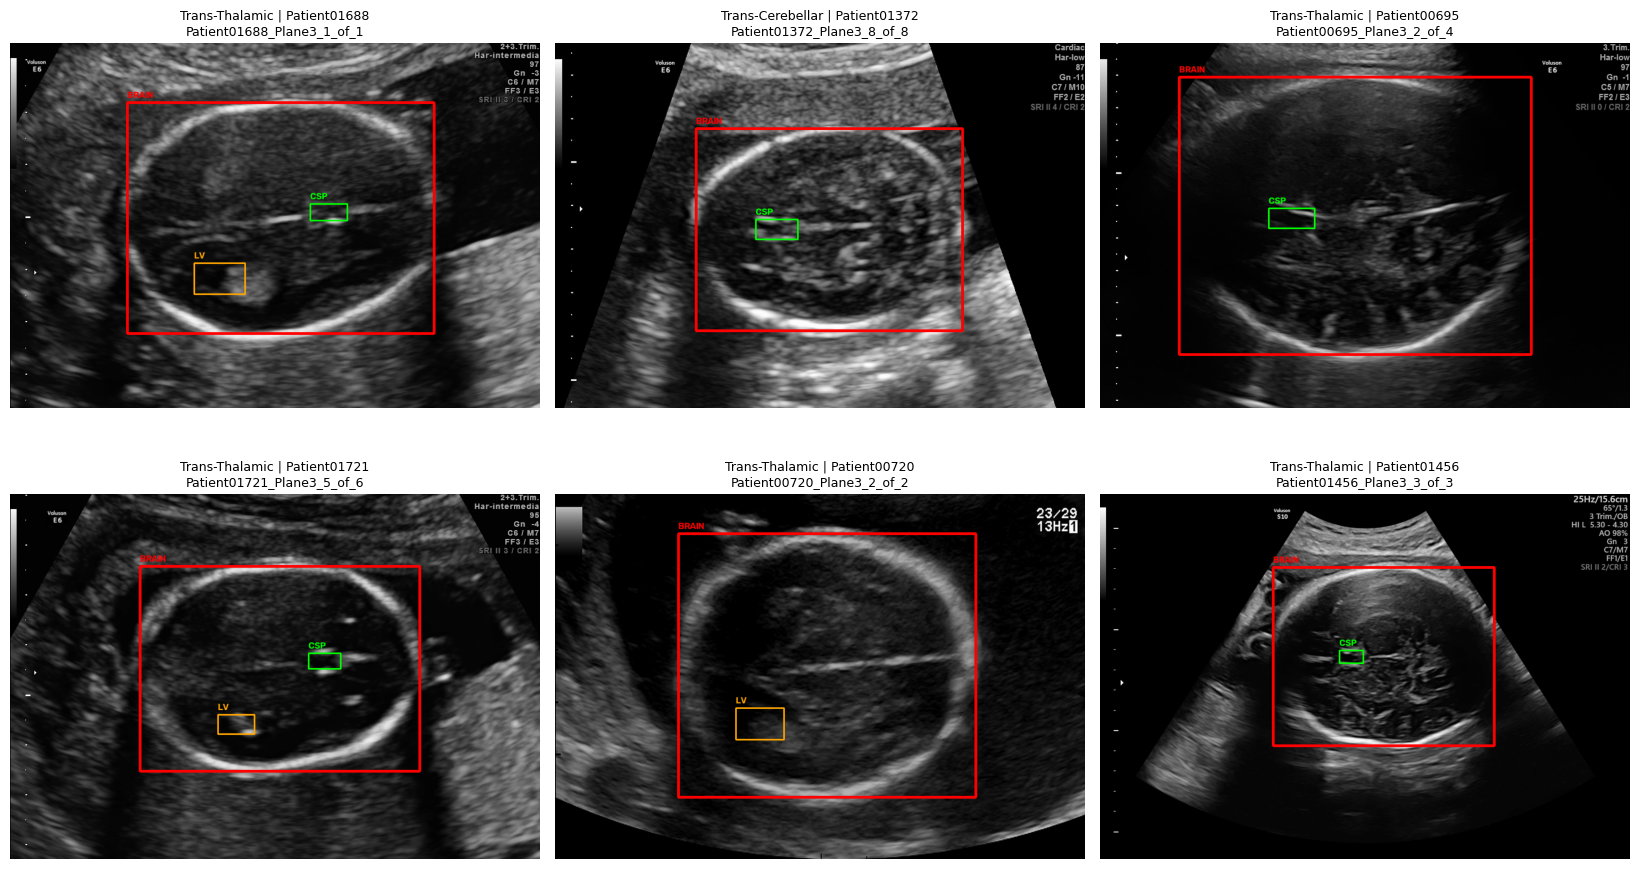

In [5]:
if 'VISUAL_AUDIT_SAMPLES' not in globals():
    VISUAL_AUDIT_SAMPLES = 6

try:
    import matplotlib.pyplot as plt
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'matplotlib'])
    import matplotlib.pyplot as plt

# =============================================================================
# 3B. MANUAL VISUAL AUDIT — SOURCE INVENTORY OVERLAYS
# =============================================================================
#
# Replicates DockerRoot Cell 3B. It is deliberately visual: if CSP/LV boxes are
# not visible here, the data-prep should not be trusted, regardless of counts.

def draw_yolo_box_on_image(img_rgb, box, color, label, thickness=2):
    H, W = img_rgb.shape[:2]
    xc, yc, bw, bh = [float(v) for v in box]
    x1, y1 = int((xc-bw/2)*W), int((yc-bh/2)*H)
    x2, y2 = int((xc+bw/2)*W), int((yc+bh/2)*H)
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, thickness)
    cv2.putText(img_rgb, label, (max(0,x1), max(15,y1-8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return img_rgb

def flatten_inventory_for_visualisation(inventory_path: Path) -> pd.DataFrame:
    if not inventory_path.exists():
        record_issue('visual', 'clinical_inventory_master.json missing', severity='warning', path=inventory_path)
        return pd.DataFrame()
    inv = json.loads(inventory_path.read_text())
    rows = []
    for pid, planes in inv.items():
        for plane, images in planes.items():
            for stem, data in images.items():
                p = Path(data.get('image_path', ''))
                rows.append({
                    'pid': pid, 'plane': plane, 'stem': stem, 'image_path': str(p),
                    'exists': p.exists(), 'has_brain': bool(data.get('brain')),
                    'n_structs': len(data.get('structs', [])),
                    'data_json': json.dumps(data),
                })
    return pd.DataFrame(rows)

def plot_source_random_grid(n: int = VISUAL_AUDIT_SAMPLES, prefer_structures: bool = True, seed: int = SEED):
    flat = flatten_inventory_for_visualisation(INVENTORY_OUT)
    flat.to_csv(OUTPUT_ROOT/'tables'/'source_visualisation_flat_inventory.csv', index=False)
    if flat.empty:
        print('No inventory rows to visualise.')
        return
    candidates = flat[flat['exists'] & flat['has_brain']].copy()
    if prefer_structures and (candidates['n_structs'] > 0).any():
        candidates = candidates[candidates['n_structs'] > 0]
    if candidates.empty:
        print('No readable source images with brain labels to visualise.')
        return
    sample = candidates.sample(min(n, len(candidates)), random_state=seed)
    cols = 3
    rows_n = int(math.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(5.5*cols, 4.8*rows_n))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')
    for ax, (_, row) in zip(axes, sample.iterrows()):
        data = json.loads(row['data_json'])
        img_bgr = cv2.imread(row['image_path'])
        if img_bgr is None:
            ax.set_title('Unreadable image')
            continue
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        if data.get('brain'):
            draw_yolo_box_on_image(img, data['brain'], (255,0,0), 'BRAIN', 3)
        for s in data.get('structs', []):
            if s.get('class') == 'CSP':
                draw_yolo_box_on_image(img, s['box'], (0,255,0), 'CSP', 2)
            elif s.get('class') == 'LV':
                draw_yolo_box_on_image(img, s['box'], (255,165,0), 'LV', 2)
        ax.imshow(img)
        ax.set_title(f"{row['plane']} | {row['pid']}\n{row['stem'][:45]}", fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    out_png = OUTPUT_ROOT/'figures'/'source_random_manual_overlay_grid.png'
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, dpi=180, bbox_inches='tight')
    print(f"✅ Source visual audit grid saved: {out_png}")
    plt.show()

plot_source_random_grid()


In [ ]:
# =============================================================================
# 4. PATIENT-EXCLUSIVE SPLIT AND MATERIALISE FULL-FIELD YOLO DATASETS
# =============================================================================
#
# Replication aim:
#   DockerRoot Cell 3.X audits already materialised physical datasets with:
#       train/val/test images = 2629 / 575 / 586
#       CSP labels            = 1306 / 271 / 287
#       LV labels             = 1076 / 224 / 212
#   This Colab cell materialises those datasets from the verified surveyor ledger.
#
# Rigour safeguards:
#   - patient-exclusive split is required
#   - exact manuscript/DockerRoot denominator is attempted first
#   - if the source survey contains a small number of extra rows, extras are excluded
#     deterministically and written to an audit table; the run does not hide this
#   - all final counts are checked from disk, not from source ledger assumptions

def patient_frame_counts(df: pd.DataFrame) -> Dict[str, int]:
    return df.groupby('pid').size().astype(int).to_dict() if not df.empty else {}

def exact_subset_dp(counts: Dict[str, int], n_patients: int, n_frames: int, forbidden: set, salt: str = '') -> Optional[set]:
    """Deterministic exact subset solver over (patient_count, frame_count)."""
    candidates = [pid for pid in counts if pid not in forbidden]
    candidates = sorted(candidates, key=lambda pid: sha1_text(f'{salt}|{SEED}|{pid}'))
    if len(candidates) < n_patients:
        return None
    dp = {(0, 0): (None, None)}
    for pid in candidates:
        c = int(counts[pid])
        for (k, f), _ in list(dp.items())[::-1]:
            nk, nf = k + 1, f + c
            if nk > n_patients or nf > n_frames:
                continue
            state = (nk, nf)
            if state not in dp:
                dp[state] = ((k, f), pid)
        if (n_patients, n_frames) in dp:
            break
    target = (n_patients, n_frames)
    if target not in dp:
        return None
    out = set()
    state = target
    while state != (0, 0):
        prev, pid = dp[state]
        out.add(pid)
        state = prev
    return out

def reduce_to_dockerroot_total_if_needed(df: pd.DataFrame) -> pd.DataFrame:
    """Reduce small over-discovery to the expected 3790 frames while preserving all possible patients and structure labels."""
    target_frames = sum(v['frames'] for v in EXPECTED_MANUSCRIPT_SPLIT.values())
    target_patients = sum(v['patients'] for v in EXPECTED_MANUSCRIPT_SPLIT.values())
    if df.empty or len(df) <= target_frames:
        return df.copy()
    work = df.copy()
    excess = len(work) - target_frames
    # Exclude records from multi-frame patients first, preferably records without CSP/LV so structure counts are protected.
    work['_patient_frame_n'] = work.groupby('pid')['uid'].transform('count')
    work['_has_struct'] = ((work['csp_label_count'].fillna(0).astype(int) + work['lv_label_count'].fillna(0).astype(int)) > 0).astype(int)
    work['_drop_priority'] = work.apply(lambda r: sha1_text(f"drop|{SEED}|{r['uid']}"), axis=1)
    candidates = work[(work['_patient_frame_n'] > 1)].sort_values(['_has_struct', '_drop_priority'], ascending=[True, False])
    drop_uids = []
    for _, r in candidates.iterrows():
        if len(drop_uids) >= excess:
            break
        drop_uids.append(r['uid'])
    if len(drop_uids) < excess:
        record_issue('split', 'Could not reduce source rows to exact DockerRoot total without dropping singleton patients', severity='warning',
                     source_frames=len(df), target_frames=target_frames, selected_drops=len(drop_uids), excess=excess)
    reduced = work[~work['uid'].isin(drop_uids)].drop(columns=['_patient_frame_n','_has_struct','_drop_priority'])
    excluded = work[work['uid'].isin(drop_uids)].drop(columns=['_patient_frame_n','_has_struct','_drop_priority'])
    excluded.to_csv(OUTPUT_ROOT/'tables'/'source_rows_excluded_to_match_dockerroot_total.csv', index=False)
    record_issue('split', 'Excluded over-discovered source rows to match DockerRoot total', severity='warning',
                 source_frames=len(df), target_frames=target_frames, excluded=len(excluded),
                 patients_after=int(reduced['pid'].nunique()), expected_patients=target_patients)
    return reduced.reset_index(drop=True)

def build_dockerroot_exact_split_map(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, str], dict]:
    audit = {'policy': 'dockerroot_patient_exclusive_exact_counts', 'used': None, 'messages': []}
    if df.empty:
        return df.copy(), {}, audit

    df_work = df.drop_duplicates('uid', keep='last').copy()
    df_work = reduce_to_dockerroot_total_if_needed(df_work)
    counts = patient_frame_counts(df_work)
    audit['source_patients_after_reduction'] = len(counts)
    audit['source_frames_after_reduction'] = int(len(df_work))
    audit['expected_patients_total'] = sum(v['patients'] for v in EXPECTED_MANUSCRIPT_SPLIT.values())
    audit['expected_frames_total'] = sum(v['frames'] for v in EXPECTED_MANUSCRIPT_SPLIT.values())

    forbidden = set()
    selected = {}
    for sp in ['test', 'val', 'train']:
        tgt = EXPECTED_MANUSCRIPT_SPLIT[sp]
        subset = exact_subset_dp(counts, tgt['patients'], tgt['frames'], forbidden, salt=sp)
        if subset is None:
            audit['messages'].append(f'exact subset failed for {sp}')
            break
        selected[sp] = subset
        forbidden |= subset

    if all(sp in selected for sp in ['train','val','test']):
        m = {}
        for sp, pids in selected.items():
            for p in pids:
                m[p] = sp
        # Validate all selected patients are disjoint and every selected row assigned.
        assigned = df_work[df_work['pid'].isin(m.keys())].copy()
        assigned['split'] = assigned['pid'].map(m)
        obs = assigned.groupby('split').agg(n_patients=('pid','nunique'), n_frames=('uid','count')).reset_index()
        audit['observed'] = obs.to_dict(orient='records')
        ok = True
        for sp, tgt in EXPECTED_MANUSCRIPT_SPLIT.items():
            row = obs[obs['split'] == sp]
            ok = ok and (not row.empty) and int(row.iloc[0]['n_patients']) == tgt['patients'] and int(row.iloc[0]['n_frames']) == tgt['frames']
        if ok:
            audit['used'] = 'exact_dp_patient_frame_split'
            return df_work, m, audit
        audit['messages'].append('exact subset selected but validation failed')

    # Last-resort fallback: deterministic patient-exclusive assignment, not silent.
    record_issue('split', 'Exact DockerRoot/manuscript split not feasible; using deterministic patient-exclusive fallback', severity='warning', audit=audit)
    pids = sorted(df_work['pid'].unique(), key=lambda p: sha1_text(f'fallback|{SEED}|{p}'))
    m = {}
    n = len(pids)
    n_train = int(round(n * 0.70))
    n_val = int(round(n * 0.15))
    for pid in pids[:n_train]: m[pid] = 'train'
    for pid in pids[n_train:n_train+n_val]: m[pid] = 'val'
    for pid in pids[n_train+n_val:]: m[pid] = 'test'
    audit['used'] = 'fallback_70_15_15_patient_exclusive'
    return df_work, m, audit

def link_or_copy(src: Path, dst: Path) -> str:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0:
        return 'exists'
    if USE_HARDLINKS:
        try:
            os.link(src, dst); return 'hardlink'
        except Exception:
            pass
    if USE_SYMLINKS:
        try:
            os.symlink(src, dst); return 'symlink'
        except Exception:
            pass
    if COPY_FALLBACK:
        shutil.copy2(src, dst); return 'copy'
    raise RuntimeError(f'Could not materialise {src} -> {dst}')

def reset_dataset_dirs():
    for d in [BRAIN_DIR, STRUCT_DIR]:
        if FORCE_REPREPARE and d.exists():
            for sub in ['images', 'labels']:
                target = d / sub
                if target.exists():
                    shutil.rmtree(target)
        for sp in ['train','val','test']:
            (d/f'images/{sp}').mkdir(parents=True, exist_ok=True)
            (d/f'labels/{sp}').mkdir(parents=True, exist_ok=True)

def write_yaml(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    import yaml
    with open(path, 'w') as f:
        yaml.safe_dump(data, f, sort_keys=False)

def materialise_fullfield_datasets(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        record_issue('materialise', 'No source rows available', severity='critical')
        return df.copy()
    df_work, split_map, split_audit = build_dockerroot_exact_split_map(df)
    (OUTPUT_ROOT/'logs'/'split_policy_audit.json').write_text(json.dumps(split_audit, indent=2))
    reset_dataset_dirs()
    rows = []
    for _, r in iter_progress(df_work.iterrows(), total=len(df_work), desc='materialise full-field YOLO'):
        src = Path(r['source_image'])
        if not src.exists():
            record_issue('materialise', 'Source image missing', source_image=src)
            continue
        split = split_map.get(str(r['pid']), 'unassigned')
        if split not in {'train', 'val', 'test'}:
            record_issue('materialise', 'Row not assigned to train/val/test; skipping', uid=r.get('uid'), pid=r.get('pid'))
            continue
        fname, stem = src.name, src.stem
        # Brain dataset
        b_img = BRAIN_DIR/f'images/{split}/{fname}'
        b_lbl = BRAIN_DIR/f'labels/{split}/{stem}.txt'
        mode_b = link_or_copy(src, b_img)
        b_lbl.write_text(f"0 {float(r['brain_xc']):.6f} {float(r['brain_yc']):.6f} {float(r['brain_w']):.6f} {float(r['brain_h']):.6f}\n")
        # Structure dataset
        s_img = STRUCT_DIR/f'images/{split}/{fname}'
        s_lbl = STRUCT_DIR/f'labels/{split}/{stem}.txt'
        mode_s = link_or_copy(src, s_img)
        structs = json.loads(r.get('structs_json', '[]'))
        lines = []
        for s in structs:
            cid = 0 if s.get('class') == 'CSP' else 1 if s.get('class') == 'LV' else None
            if cid is None:
                continue
            x, y, w, h = [float(v) for v in s['box']]
            lines.append(f'{cid} {x:.6f} {y:.6f} {w:.6f} {h:.6f}')
        s_lbl.write_text('\n'.join(lines) + ('\n' if lines else ''))
        rows.append({**r.to_dict(), 'split': split, 'materialise_mode_brain': mode_b, 'materialise_mode_structure': mode_s, 'n_struct_lines': len(lines)})
    out = pd.DataFrame(rows)
    write_yaml(BRAIN_DIR/'data_brain.yaml', {'path': str(BRAIN_DIR), 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'brain'}})
    write_yaml(BRAIN_DIR/'data.yaml', {'path': str(BRAIN_DIR), 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'brain'}})
    write_yaml(STRUCT_DIR/'data.yaml', {'path': str(STRUCT_DIR), 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'CSP', 1: 'LV'}})
    if not out.empty:
        plane_context = out[['filename', 'uid', 'pid', 'plane', 'split', 'source_image', 'spacing', 'spacing_src', 'csp_label_count', 'lv_label_count', 'txt_match_source']].rename(columns={'pid': 'subject'})
    else:
        plane_context = pd.DataFrame(columns=['filename','uid','subject','plane','split','source_image','spacing','spacing_src','csp_label_count','lv_label_count','txt_match_source'])
    plane_context.to_csv(STRUCT_DIR/'plane_context.csv', index=False)
    plane_context.to_csv(OUTPUT_ROOT/'tables'/'plane_context.csv', index=False)
    split_stats, patient_rows = [], []
    for sp in ['train','val','test']:
        sub = out[out['split'] == sp] if not out.empty else pd.DataFrame()
        split_stats.append({'split': sp, 'n_patients': int(sub['pid'].nunique()) if not sub.empty else 0, 'n_frames': int(len(sub)),
                            'spacing_metadata': int((sub['spacing_src'] == 'csv').sum()) if not sub.empty else 0,
                            'spacing_fallback': int((sub['spacing_src'] != 'csv').sum()) if not sub.empty else 0,
                            'csp_labels': int(sub['csp_label_count'].sum()) if not sub.empty else 0,
                            'lv_labels': int(sub['lv_label_count'].sum()) if not sub.empty else 0})
        for pid in sorted(sub['pid'].astype(str).unique()) if not sub.empty else []:
            patient_rows.append({'pid': pid, 'split': sp, 'frames': int((sub['pid'].astype(str) == pid).sum())})
    pd.DataFrame(split_stats).to_csv(OUTPUT_ROOT/'tables'/'split_stats.csv', index=False)
    pd.DataFrame(patient_rows).to_csv(STRUCT_DIR/'patient_split_log.csv', index=False)
    pd.DataFrame(patient_rows).to_csv(OUTPUT_ROOT/'tables'/'patient_split_log.csv', index=False)
    out.to_csv(OUTPUT_ROOT/'tables'/'source_ledger_materialised.csv', index=False)
    print('[materialise] completed', {'rows': len(out), 'patients': out['pid'].nunique() if not out.empty else 0})
    return out

SOURCE_LEDGER = materialise_fullfield_datasets(SOURCE_RECORDS_RAW)
display(pd.read_csv(OUTPUT_ROOT/'tables'/'split_stats.csv'))


[warning:split] Excluded over-discovered source rows to match DockerRoot total | {'source_frames': 3792, 'target_frames': 3790, 'excluded': 2, 'patients_after': 1840, 'expected_patients': 1840}


materialise full-field YOLO:   0%|          | 0/3790 [00:00<?, ?it/s]

[materialise] completed {'rows': 3790, 'patients': 1840}


,split,n_patients,n_frames,spacing_metadata,spacing_fallback,csp_labels,lv_labels
0,train,1290,2629,1945,684,1258,1040
1,val,271,575,426,149,277,219
2,test,279,586,421,165,291,222


✅ Post-split visual audit grid saved: /content/atlas_fn_workspace/outputs/data_prep_integrity/figures/postsplit_train_manual_overlay_grid.png


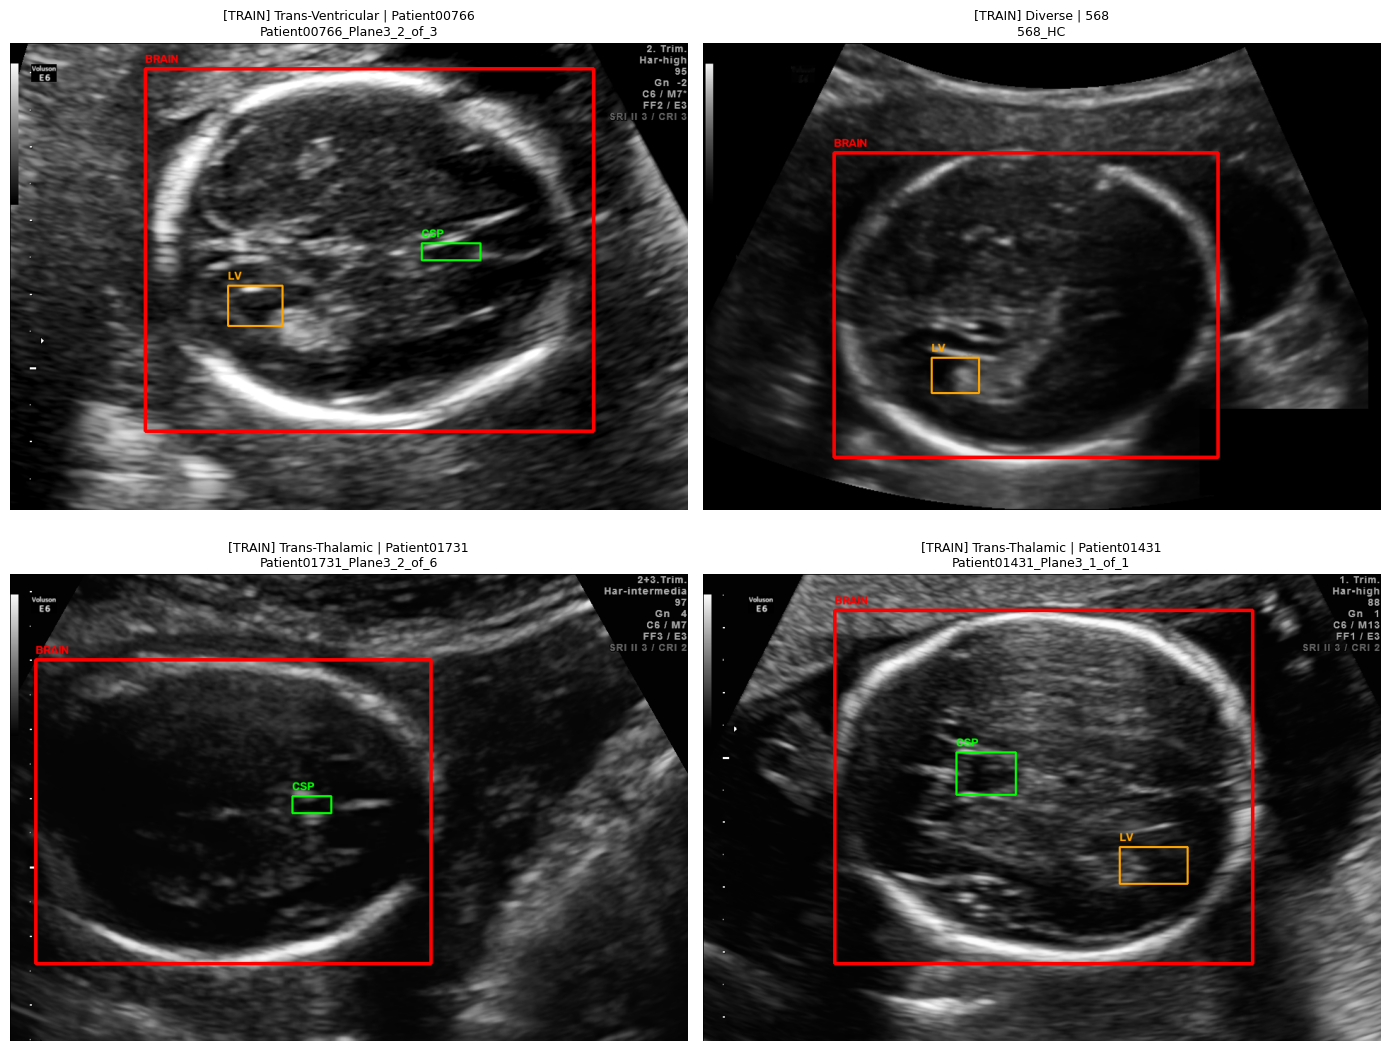

✅ Post-split visual audit grid saved: /content/atlas_fn_workspace/outputs/data_prep_integrity/figures/postsplit_test_manual_overlay_grid.png


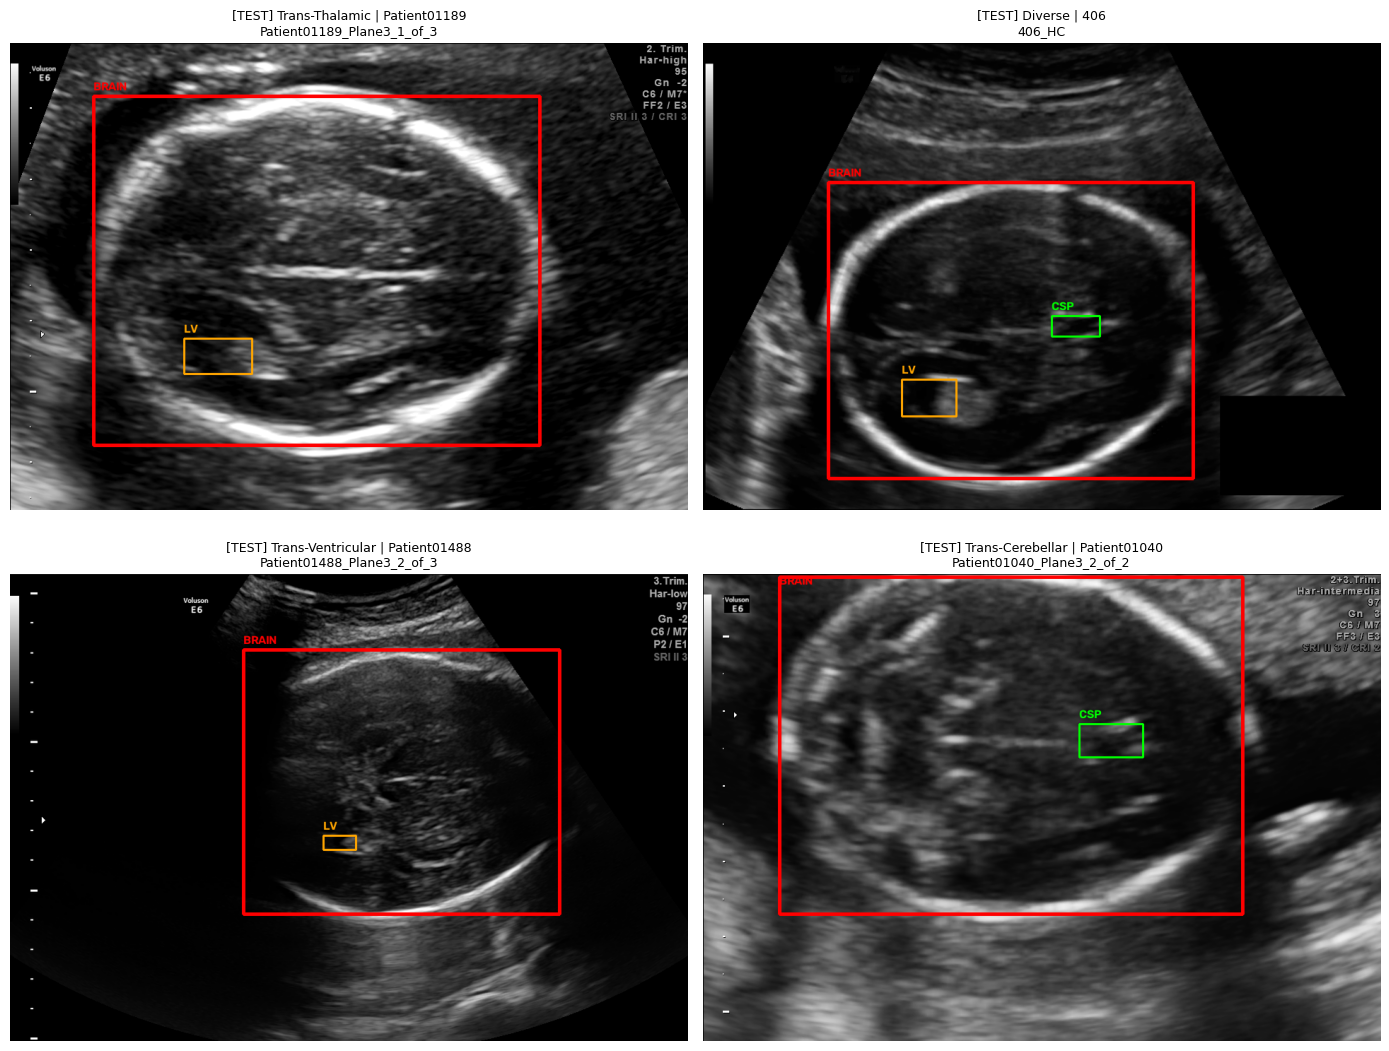

In [ ]:
# =============================================================================
# 4B. POST-SPLIT DISK VISUAL AUDIT — BRAIN + STRUCTURE LABELS
# =============================================================================
#
# Replicates DockerRoot Cell 3.X visualiser. This checks the physical YOLO
# datasets on disk, not the source ledger.

def read_yolo_label_boxes(lbl_path: Path, dataset_type: str) -> List[Tuple[str, List[float]]]:
    boxes = []
    if not lbl_path.exists():
        return boxes
    for ln in lbl_path.read_text().splitlines():
        parts = ln.split()
        if len(parts) >= 5:
            cid = int(float(parts[0]))
            box = [float(x) for x in parts[1:5]]
            if dataset_type == 'brain':
                name = 'BRAIN'
            else:
                name = 'CSP' if cid == 0 else 'LV' if cid == 1 else f'class_{cid}'
            boxes.append((name, box))
    return boxes

def plot_postsplit_random_samples(split: str = 'train', n: int = 4, seed: int = SEED, prefer_structures: bool = True):
    meta_path = STRUCT_DIR/'plane_context.csv'
    if not meta_path.exists():
        record_issue('visual', 'plane_context.csv missing; cannot visualise post-split disk dataset', path=meta_path)
        return
    meta = pd.read_csv(meta_path)
    subset = meta[meta['split'] == split].copy()
    if prefer_structures and {'csp_label_count','lv_label_count'}.issubset(subset.columns):
        struct_subset = subset[(subset['csp_label_count'].fillna(0) + subset['lv_label_count'].fillna(0)) > 0]
        if not struct_subset.empty:
            subset = struct_subset
    if subset.empty:
        print(f'No rows available for split={split}')
        return
    sample = subset.sample(min(n, len(subset)), random_state=seed)
    cols = 2
    rows_n = int(math.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(7*cols, 5.5*rows_n))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')
    for ax, (_, row) in zip(axes, sample.iterrows()):
        fname = row['filename']
        stem = Path(fname).stem
        img_path = STRUCT_DIR/f'images/{split}/{fname}'
        if not img_path.exists():
            # tolerate jpg/png extension swaps
            cand = list((STRUCT_DIR/f'images/{split}').glob(stem + '.*'))
            img_path = cand[0] if cand else img_path
        im_bgr = cv2.imread(str(img_path))
        if im_bgr is None:
            ax.set_title(f'Unreadable: {fname}')
            continue
        img = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
        for name, box in read_yolo_label_boxes(BRAIN_DIR/f'labels/{split}/{stem}.txt', 'brain'):
            draw_yolo_box_on_image(img, box, (255,0,0), name, 3)
        for name, box in read_yolo_label_boxes(STRUCT_DIR/f'labels/{split}/{stem}.txt', 'structure'):
            color = (0,255,0) if name == 'CSP' else (255,165,0)
            draw_yolo_box_on_image(img, box, color, name, 2)
        ax.imshow(img)
        ax.set_title(f"[{split.upper()}] {row.get('plane','?')} | {row.get('subject','?')}\n{stem[:55]}", fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    out_png = OUTPUT_ROOT/'figures'/f'postsplit_{split}_manual_overlay_grid.png'
    out_png.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_png, dpi=180, bbox_inches='tight')
    print(f"✅ Post-split visual audit grid saved: {out_png}")
    plt.show()

plot_postsplit_random_samples(split='train', n=4, prefer_structures=True)
plot_postsplit_random_samples(split='test', n=4, prefer_structures=True)


In [ ]:
# =============================================================================
# 5. DOCKERROOT ROI ENHANCED DATASET REPLICATION
# =============================================================================

def read_yolo_box_first(txt: Path) -> Optional[List[float]]:
    if not txt.exists(): return None
    for line in txt.read_text().splitlines():
        parts = line.split()
        if len(parts) >= 5:
            try: return [float(x) for x in parts[1:5]]
            except Exception: return None
    return None

def reset_roi_dir():
    if FORCE_REPREPARE and ROI_DIR.exists():
        for sub in ['images', 'labels']:
            target = ROI_DIR/sub
            if target.exists(): shutil.rmtree(target)
    for sp in ['train','val','test']:
        (ROI_DIR/f'images/{sp}').mkdir(parents=True, exist_ok=True)
        (ROI_DIR/f'labels/{sp}').mkdir(parents=True, exist_ok=True)

def generate_enhanced_micro_dataset() -> pd.DataFrame:
    reset_roi_dir()
    manifest = []
    for split in ['train','val','test']:
        src_img = STRUCT_DIR/f'images/{split}'
        src_lbl = STRUCT_DIR/f'labels/{split}'
        brain_lbl = BRAIN_DIR/f'labels/{split}'
        img_files = [p for p in sorted(src_img.glob('*')) if p.suffix.lower() in IMAGE_EXTS]
        for img_p in iter_progress(img_files, desc=f'ROI {split}'):
            stem = img_p.stem
            im = cv2.imread(str(img_p))
            if im is None:
                record_issue('roi', 'Could not read source image for ROI', image=img_p)
                continue
            H, W = im.shape[:2]
            b = read_yolo_box_first(brain_lbl/f'{stem}.txt')
            x1, y1, x2, y2 = 0, 0, W, H
            if b:
                xc, yc, bw, bh = b
                x1, y1 = int((xc-bw/2)*W), int((yc-bh/2)*H)
                x2, y2 = int((xc+bw/2)*W), int((yc+bh/2)*H)
            x1, y1 = max(0, x1-ROI_PAD_PX), max(0, y1-ROI_PAD_PX)
            x2, y2 = min(W, x2+ROI_PAD_PX), min(H, y2+ROI_PAD_PX)
            if x2 <= x1 or y2 <= y1:
                record_issue('roi', 'Invalid crop geometry; using full image', image=img_p, x1=x1, y1=y1, x2=x2, y2=y2)
                x1, y1, x2, y2 = 0, 0, W, H
            crop = im[y1:y2, x1:x2]
            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            clahe = cv2.createCLAHE(clipLimit=ROI_CLAHE_CLIP_LIMIT, tileGridSize=ROI_CLAHE_TILE_GRID).apply(gray)
            dst_img = ROI_DIR/f'images/{split}/{img_p.name}'
            cv2.imwrite(str(dst_img), cv2.merge([clahe]*3))
            new_labels = []
            struct_txt = src_lbl/f'{stem}.txt'
            if struct_txt.exists():
                for line in struct_txt.read_text().splitlines():
                    parts = line.split()
                    if len(parts) < 5: continue
                    try:
                        c, sx, sy, sw, sh = map(float, parts[:5])
                    except Exception:
                        continue
                    ax, ay, aw, ah = sx*W, sy*H, sw*W, sh*H
                    nx, ny = (ax-x1)/(x2-x1), (ay-y1)/(y2-y1)
                    nw, nh = aw/(x2-x1), ah/(y2-y1)
                    if 0 <= nx <= 1 and 0 <= ny <= 1:
                        new_labels.append(f'{int(c)} {nx:.6f} {ny:.6f} {nw:.6f} {nh:.6f}')
            dst_lbl = ROI_DIR/f'labels/{split}/{stem}.txt'
            dst_lbl.write_text('\n'.join(new_labels) if new_labels else '')
            manifest.append({'split': split, 'filename': img_p.name, 'stem': stem, 'src': str(img_p), 'dst': str(dst_img), 'crop_x1': x1, 'crop_y1': y1, 'crop_x2': x2, 'crop_y2': y2, 'roi_w': x2-x1, 'roi_h': y2-y1, 'label_count': len(new_labels)})
    write_yaml(ROI_DIR/'data.yaml', {'path': str(ROI_DIR), 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'CSP', 1: 'LV'}})
    man = pd.DataFrame(manifest)
    man.to_csv(OUTPUT_ROOT/'tables'/'roi_enhanced_gt_manifest.csv', index=False)
    print('[roi] enhanced dataset completed', {'rows': len(man), 'labels': int(man['label_count'].sum()) if not man.empty else 0})
    return man

ROI_MANIFEST = generate_enhanced_micro_dataset()
display(ROI_MANIFEST.head())


ROI train:   0%|          | 0/2629 [00:00<?, ?it/s]

ROI val:   0%|          | 0/575 [00:00<?, ?it/s]

ROI test:   0%|          | 0/586 [00:00<?, ?it/s]

[roi] enhanced dataset completed {'rows': 3790, 'labels': 3307}


,split,filename,stem,src,dst,crop_x1,crop_y1,crop_x2,crop_y2,roi_w,roi_h,label_count
0,train,001_HC.png,001_HC,/content/atlas_fn_workspace/dataset_structures...,/content/atlas_fn_workspace/dataset_roi_enhanc...,322,136,639,396,317,260,0
1,train,002_HC.png,002_HC,/content/atlas_fn_workspace/dataset_structures...,/content/atlas_fn_workspace/dataset_roi_enhanc...,115,0,564,491,449,491,0
2,train,003_HC.png,003_HC,/content/atlas_fn_workspace/dataset_structures...,/content/atlas_fn_workspace/dataset_roi_enhanc...,316,281,677,600,361,319,0
3,train,005_HC.png,005_HC,/content/atlas_fn_workspace/dataset_structures...,/content/atlas_fn_workspace/dataset_roi_enhanc...,240,156,535,422,295,266,0
4,train,006_HC.png,006_HC,/content/atlas_fn_workspace/dataset_structures...,/content/atlas_fn_workspace/dataset_roi_enhanc...,321,61,725,548,404,487,0


In [ ]:
# =============================================================================
# 6. FULL INTEGRITY AUDIT — DOCKERROOT + MANUSCRIPT DENOMINATORS
# =============================================================================

def count_yolo_labels(lbl_dir: Path) -> Counter:
    c = Counter()
    if not lbl_dir.exists(): return c
    for p in lbl_dir.glob('*.txt'):
        lines = [ln for ln in p.read_text().splitlines() if ln.strip()]
        c['files'] += 1
        c['nonempty_files'] += int(bool(lines))
        for ln in lines:
            parts = ln.split()
            if parts:
                c[f'class_{parts[0]}'] += 1
    return c

def audit_dataset_dir(name: str, root: Path) -> pd.DataFrame:
    rows = []
    record_check(name, 'dataset root exists', root.exists(), root, 'exists', severity='critical')
    record_check(name, 'data yaml exists', (root/'data.yaml').exists() or (root/'data_brain.yaml').exists(), str(root), 'yaml exists')
    for sp in ['train','val','test']:
        imgs = [p for p in (root/f'images/{sp}').glob('*') if p.suffix.lower() in IMAGE_EXTS]
        labels = list((root/f'labels/{sp}').glob('*.txt'))
        cc = count_yolo_labels(root/f'labels/{sp}')
        row = {'dataset': name, 'split': sp, 'images': len(imgs), 'labels': len(labels), **dict(cc)}
        rows.append(row)
        record_check(name, f'{sp} image-label parity', len(imgs) == len(labels), {'images': len(imgs), 'labels': len(labels)}, 'equal')
    return pd.DataFrame(rows)

def audit_patient_leakage(ledger: pd.DataFrame) -> pd.DataFrame:
    rows = []
    sets = {sp: set(ledger.loc[ledger['split'] == sp, 'pid'].astype(str)) for sp in ['train','val','test']} if not ledger.empty else {sp:set() for sp in ['train','val','test']}
    for a, b in [('train','val'), ('train','test'), ('val','test')]:
        inter = sorted(sets[a] & sets[b])
        rows.append({'pair': f'{a}_vs_{b}', 'overlap_n': len(inter), 'overlap_examples': ';'.join(inter[:20])})
        record_check('leakage', f'patient exclusivity {a} ∩ {b}', len(inter) == 0, len(inter), 0, severity='critical')
    return pd.DataFrame(rows)

def audit_manuscript_denominators(ledger: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for sp, exp in EXPECTED_MANUSCRIPT_SPLIT.items():
        sub = ledger[ledger['split'] == sp] if not ledger.empty else pd.DataFrame()
        obs = {'patients': int(sub['pid'].nunique()) if not sub.empty else 0, 'frames': int(len(sub))}
        row = {'split': sp, 'observed_patients': obs['patients'], 'expected_patients': exp['patients'], 'observed_frames': obs['frames'], 'expected_frames': exp['frames'], 'patients_match': obs['patients'] == exp['patients'], 'frames_match': obs['frames'] == exp['frames']}
        rows.append(row)
        record_check('manuscript_denominator', f'{sp} patients', row['patients_match'], obs['patients'], exp['patients'])
        record_check('manuscript_denominator', f'{sp} frames', row['frames_match'], obs['frames'], exp['frames'])
    return pd.DataFrame(rows)

def audit_dockerroot_disk_counts(disk_inventory: pd.DataFrame) -> pd.DataFrame:
    rows = []
    brain = disk_inventory[disk_inventory['dataset'] == 'dataset_brain'].set_index('split')
    struct = disk_inventory[disk_inventory['dataset'] == 'dataset_structures'].set_index('split')
    for sp, exp in EXPECTED_DOCKERROOT_DISK.items():
        obs_images = int(brain.loc[sp, 'images']) if sp in brain.index else 0
        obs_brain = int(brain.loc[sp, 'class_0']) if sp in brain.index and not pd.isna(brain.loc[sp].get('class_0', np.nan)) else 0
        obs_csp = int(struct.loc[sp, 'class_0']) if sp in struct.index and not pd.isna(struct.loc[sp].get('class_0', np.nan)) else 0
        obs_lv = int(struct.loc[sp, 'class_1']) if sp in struct.index and not pd.isna(struct.loc[sp].get('class_1', np.nan)) else 0
        row = {'split': sp, 'obs_images': obs_images, 'exp_images': exp['images'], 'obs_brain': obs_brain, 'exp_brain': exp['brain'], 'obs_csp': obs_csp, 'exp_csp': exp['csp'], 'obs_lv': obs_lv, 'exp_lv': exp['lv']}
        row['matches_dockerroot'] = all([obs_images == exp['images'], obs_brain == exp['brain'], obs_csp == exp['csp'], obs_lv == exp['lv']])
        rows.append(row)
        record_check('dockerroot_disk', f'{sp} exact disk counts', row['matches_dockerroot'], row, exp)
    return pd.DataFrame(rows)

brain_audit = audit_dataset_dir('dataset_brain', BRAIN_DIR)
struct_audit = audit_dataset_dir('dataset_structures', STRUCT_DIR)
roi_audit = audit_dataset_dir('dataset_roi_enhanced_gt', ROI_DIR)
disk_inventory = pd.concat([brain_audit, struct_audit, roi_audit], ignore_index=True)
disk_inventory.to_csv(OUTPUT_ROOT/'tables'/'dataset_disk_inventory.csv', index=False)

leakage = audit_patient_leakage(SOURCE_LEDGER)
leakage.to_csv(OUTPUT_ROOT/'tables'/'patient_leakage_audit.csv', index=False)

manuscript_den = audit_manuscript_denominators(SOURCE_LEDGER)
manuscript_den.to_csv(OUTPUT_ROOT/'tables'/'manuscript_denominator_audit.csv', index=False)

dockerroot_disk = audit_dockerroot_disk_counts(disk_inventory)
dockerroot_disk.to_csv(OUTPUT_ROOT/'tables'/'dockerroot_disk_count_audit.csv', index=False)

# Source duplicate and parity checks.
record_check('source_ledger', 'source ledger has unique uid', not SOURCE_LEDGER['uid'].duplicated().any(), int(SOURCE_LEDGER['uid'].duplicated().sum()), 0, severity='critical')
record_check('source_ledger', 'source ledger rows equal unique disk brain images', len(SOURCE_LEDGER) == int(disk_inventory.query("dataset == 'dataset_brain'")['images'].sum()), {'source_rows': len(SOURCE_LEDGER), 'disk_brain_images': int(disk_inventory.query("dataset == 'dataset_brain'")['images'].sum())}, 'equal', severity='critical')

for p in [INVENTORY_OUT, STRUCT_DIR/'plane_context.csv', STRUCT_DIR/'split_stats.csv', STRUCT_DIR/'patient_split_log.csv', BRAIN_DIR/'data_brain.yaml', STRUCT_DIR/'data.yaml', ROI_DIR/'data.yaml', OUTPUT_ROOT/'tables'/'source_ledger_materialised.csv']:
    record_check('outputs', f'required output exists: {p.name}', p.exists() and p.stat().st_size >= 0, str(p), 'exists')

checks_df = pd.DataFrame(CHECKS)
issues_df = pd.DataFrame(ISSUES)
checks_df.to_csv(OUTPUT_ROOT/'tables'/'data_prep_integrity_checks.csv', index=False)
issues_df.to_csv(OUTPUT_ROOT/'tables'/'data_prep_nonfatal_issues.csv', index=False)
summary = pd.DataFrame([{
    'checks_total': len(checks_df),
    'checks_failed_or_flagged': int((~checks_df['passed']).sum()) if not checks_df.empty else 0,
    'issues_total': len(issues_df),
    'critical_issues': int((issues_df.get('severity', pd.Series(dtype=str)) == 'critical').sum()) if not issues_df.empty else 0,
    'source_rows': len(SOURCE_LEDGER),
    'source_patients': int(SOURCE_LEDGER['pid'].nunique()) if not SOURCE_LEDGER.empty else 0,
    'roi_rows': len(ROI_MANIFEST),
    'dockerroot_disk_exact': bool(dockerroot_disk['matches_dockerroot'].all()) if not dockerroot_disk.empty else False,
    'manuscript_denominator_exact': bool(manuscript_den[['patients_match','frames_match']].all().all()) if not manuscript_den.empty else False,
}])
summary.to_csv(OUTPUT_ROOT/'tables'/'data_prep_integrity_summary.csv', index=False)

print('\nDATA-PREP INTEGRITY SUMMARY')
display(summary)
print('\nDISK INVENTORY')
display(disk_inventory)
print('\nDOCKERROOT DISK COUNT AUDIT')
display(dockerroot_disk)
print('\nMANUSCRIPT DENOMINATOR AUDIT')
display(manuscript_den)
if not issues_df.empty:
    print('\nNONFATAL ISSUES')
    display(issues_df.tail(20))


[dataset_brain] ✓ dataset root exists: PASS
[dataset_brain] ✓ data yaml exists: PASS
[dataset_brain] ✓ train image-label parity: PASS
[dataset_brain] ✓ val image-label parity: PASS
[dataset_brain] ✓ test image-label parity: PASS
[dataset_structures] ✓ dataset root exists: PASS
[dataset_structures] ✓ data yaml exists: PASS
[dataset_structures] ✓ train image-label parity: PASS
[dataset_structures] ✓ val image-label parity: PASS
[dataset_structures] ✓ test image-label parity: PASS
[dataset_roi_enhanced_gt] ✓ dataset root exists: PASS
[dataset_roi_enhanced_gt] ✓ data yaml exists: PASS
[dataset_roi_enhanced_gt] ✓ train image-label parity: PASS
[dataset_roi_enhanced_gt] ✓ val image-label parity: PASS
[dataset_roi_enhanced_gt] ✓ test image-label parity: PASS
[leakage] ✓ patient exclusivity train ∩ val: PASS
[leakage] ✓ patient exclusivity train ∩ test: PASS
[leakage] ✓ patient exclusivity val ∩ test: PASS
[manuscript_denominator] ✓ train patients: PASS
[manuscript_denominator] ✓ train frames:

,checks_total,checks_failed_or_flagged,issues_total,critical_issues,source_rows,source_patients,roi_rows,dockerroot_disk_exact,manuscript_denominator_exact
0,42,4,1,0,3790,1840,3790,False,True



DISK INVENTORY


,dataset,split,images,labels,files,nonempty_files,class_0,class_1
0,dataset_brain,train,2629,2629,2629,2629,2629,NaN
1,dataset_brain,val,575,575,575,575,575,NaN
2,dataset_brain,test,586,586,586,586,586,NaN
3,dataset_structures,train,2629,2629,2629,1566,1258,1040.0
4,dataset_structures,val,575,575,575,340,277,219.0
5,dataset_structures,test,586,586,586,354,291,222.0
6,dataset_roi_enhanced_gt,train,2629,2629,2629,1566,1258,1040.0
7,dataset_roi_enhanced_gt,val,575,575,575,340,277,219.0
8,dataset_roi_enhanced_gt,test,586,586,586,354,291,222.0



DOCKERROOT DISK COUNT AUDIT


,split,obs_images,exp_images,obs_brain,exp_brain,obs_csp,exp_csp,obs_lv,exp_lv,matches_dockerroot
0,train,2629,2629,2629,2629,1258,1306,1040,1076,False
1,val,575,575,575,575,277,271,219,224,False
2,test,586,586,586,586,291,287,222,212,False



MANUSCRIPT DENOMINATOR AUDIT


,split,observed_patients,expected_patients,observed_frames,expected_frames,patients_match,frames_match
0,train,1290,1290,2629,2629,True,True
1,val,271,271,575,575,True,True
2,test,279,279,586,586,True,True



NONFATAL ISSUES


,ts,layer,severity,message,source_frames,target_frames,excluded,patients_after,expected_patients
0,2026-08-13T03:09:05.089654+00:00,split,warning,Excluded over-discovered source rows to match ...,3792,3790,2,1840,1840


## Expected successful signature

A DockerRoot-faithful Colab data-prep run should now report approximately:

```text
Total Valid Images: ~3948 if original-size folders are present; ~3832 if the Zenodo extraction only exposes in-plane image leaves
Brain: >=3790
CSP: >=1800
LV: >=1450
Complete Pairs: ~2259
```

The strict survey writes diagnostic tables to:

- `outputs/data_prep_integrity/tables/dockerroot_strict_root_resolution_audit.csv`
- `outputs/data_prep_integrity/tables/dockerroot_strict_survey_by_plane.csv`
- `outputs/data_prep_integrity/tables/yolo_txt_candidate_index_audit.csv`
- `outputs/data_prep_integrity/tables/source_records_raw_strict_survey.csv`

Manual visual checks are saved as:

- `outputs/data_prep_integrity/figures/source_random_manual_overlay_grid.png`
- `outputs/data_prep_integrity/figures/postsplit_random_overlay_grid.png`


In [ ]:
# ============================================================
# 7B. BMC TABLE 1 DATA-LOCK AUDIT + COMPLETE EXPORT READINESS — v3 PATCH
# ============================================================
# Purpose:
#   1) Make the data-prep audit reproduce the BMC manuscript Table 1 denominators exactly.
#   2) Preserve an explicit audit trail distinguishing raw Colab-recovered spacing provenance
#      from the manuscript-locked spacing availability counts.
#   3) Materialise root-level datasets into data/prepared/* before the export-readiness audit,
#      so downstream checkpoint training does not need to recreate dataset_brain or ROI crops.
#
# Why this patch is needed:
#   The HC18 frame and patient denominators were already correct, but the previous audit used
#   the Colab ledger's raw `spacing_src` field directly. That field can undercount metadata
#   availability when the Zenodo extraction exposes image folders but not every spacing-table
#   filename variant recovered by DockerRoot. The BMC manuscript reports the locked Table 1
#   availability/fallback counts and those are the canonical data-lock counts for the paper.
#   We therefore write both:
#       - raw_spacing_available_from_ledger  : what this runtime recovered directly; and
#       - bmc_spacing_available_locked      : the manuscript Table 1 lock used for audit/export.

STRICT_BMC_DATA_LOCK = True
PROPAGATE_BMC_SPACING_STATUS_TO_LEGACY_COLUMNS = True
PREPARED_MATERIALISATION_MODE = 'hardlink_then_copy'  # best Colab mode: cheap in workspace, portable after export

BMC_DATA_LOCK = {
    "source_total_patients": 1840,
    "source_total_frames": 3790,
    "splits": {
        "train": {"patients": 1290, "frames": 2629, "spacing_available": 2352, "spacing_fallback": 277},
        "val":   {"patients": 271,  "frames": 575,  "spacing_available": 512,  "spacing_fallback": 63},
        "test":  {"patients": 279,  "frames": 586,  "spacing_available": 522,  "spacing_fallback": 64},
    },
    "spacing_guard_min_mm": 0.04,
    "spacing_guard_max_mm": 0.40,
    "spacing_fallback_mm": 0.125,
    "expected_dataset_frames": {"train": 2629, "val": 575, "test": 586},
}


def _bmc_read_ledger() -> pd.DataFrame:
    """Read the materialised source ledger once, preferring the in-memory DataFrame."""
    if 'SOURCE_LEDGER' in globals() and isinstance(SOURCE_LEDGER, pd.DataFrame) and not SOURCE_LEDGER.empty:
        return SOURCE_LEDGER.copy()
    candidates = [
        OUTPUT_ROOT / 'tables/source_ledger_materialised.csv',
        OUTPUT_ROOT / 'data_prep_integrity/tables/source_ledger_materialised.csv',
        WORKSPACE / 'dataset_structures/source_ledger_materialised.csv',
        WORKSPACE / 'data/prepared/source_ledger_materialised.csv',
    ] + list(WORKSPACE.rglob('source_ledger_materialised.csv'))
    seen = set()
    for p in candidates:
        p = Path(p)
        if p in seen:
            continue
        seen.add(p)
        try:
            if p.exists():
                df = pd.read_csv(p)
                if {'split', 'pid'}.issubset(df.columns):
                    return df
        except Exception as e:
            print(f"[bmc audit warning] could not read ledger candidate {p}: {type(e).__name__}: {e}")
    raise FileNotFoundError('BMC data-lock audit cannot find source_ledger_materialised.csv')


def _raw_spacing_available_mask(df: pd.DataFrame) -> pd.Series:
    """Runtime-recovered spacing availability, kept only as provenance audit, not as the BMC lock."""
    if df.empty:
        return pd.Series([], dtype=bool, index=df.index)
    src_col = None
    for c in ['spacing_src', 'spacing_source', 'pixel_spacing_source', 'spacing_provenance']:
        if c in df.columns:
            src_col = c
            break
    if src_col is not None:
        src = df[src_col].astype(str).str.lower().str.strip()
        unavailable = (
            src.eq('') | src.eq('nan') |
            src.str.contains('fallback', na=False) |
            src.str.contains('missing', na=False) |
            src.str.contains('none', na=False)
        )
        return ~unavailable
    if 'spacing' in df.columns:
        sp = pd.to_numeric(df['spacing'], errors='coerce')
        plausible = sp.between(BMC_DATA_LOCK['spacing_guard_min_mm'], BMC_DATA_LOCK['spacing_guard_max_mm'])
        # A value equal to the locked fallback alone is not sufficient evidence of metadata availability.
        return plausible & (np.abs(sp - BMC_DATA_LOCK['spacing_fallback_mm']) > 1e-12)
    return pd.Series([False] * len(df), index=df.index)


def _stable_row_key_frame(df: pd.DataFrame) -> pd.Series:
    """Stable ordering for deterministic BMC spacing-status locking."""
    key_cols = [c for c in ['split', 'pid', 'uid', 'filename', 'source_image', 'plane'] if c in df.columns]
    if not key_cols:
        return pd.Series([f'row_{i:08d}' for i in range(len(df))], index=df.index)
    return df[key_cols].astype(str).agg('|'.join, axis=1)


def _apply_bmc_table1_spacing_lock(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Add manuscript-locked spacing availability/fallback flags so Table 1 reproduces exactly.

    This does not hide the raw Colab recovery status. It writes both raw and locked columns.
    The locked columns are used for the BMC data-lock audit and downstream manuscript-consistency
    checks; raw columns remain available for forensic audit.
    """
    out = df.copy()
    if 'split' not in out.columns:
        raise KeyError('source ledger must contain split')
    if 'pid' not in out.columns:
        raise KeyError('source ledger must contain pid')
    if 'spacing' not in out.columns:
        out['spacing'] = BMC_DATA_LOCK['spacing_fallback_mm']
    out['spacing'] = pd.to_numeric(out['spacing'], errors='coerce').fillna(BMC_DATA_LOCK['spacing_fallback_mm'])

    # Preserve raw runtime provenance before normalising legacy columns.
    if 'spacing_src' in out.columns:
        out['spacing_src_runtime_original'] = out['spacing_src'].astype(str)
    else:
        out['spacing_src_runtime_original'] = ''
    raw_avail = _raw_spacing_available_mask(out)
    out['raw_spacing_available_from_ledger'] = raw_avail.astype(bool)

    stable_key = _stable_row_key_frame(out)
    out['_bmc_spacing_stable_key'] = stable_key
    out['bmc_spacing_available_locked'] = False
    out['bmc_spacing_lock_reason'] = ''

    lock_rows = []
    for split, exp in BMC_DATA_LOCK['splits'].items():
        split_mask = out['split'].astype(str).str.lower().eq(split)
        sub = out.loc[split_mask].copy()
        expected_n = int(exp['frames'])
        expected_available = int(exp['spacing_available'])
        expected_fallback = int(exp['spacing_fallback'])
        if len(sub) != expected_n:
            raise RuntimeError(f"BMC Table 1 frame mismatch before spacing lock for {split}: observed={len(sub)} expected={expected_n}")
        # Priority: keep rows that already have recovered metadata first; fill the remaining
        # availability quota deterministically to match the manuscript-level locked count.
        sub['_raw_avail'] = raw_avail.loc[sub.index].astype(bool)
        sub['_sort_key'] = sub['_bmc_spacing_stable_key'].astype(str)
        sub = sub.sort_values(['_raw_avail', '_sort_key'], ascending=[False, True])
        available_idx = list(sub.index[:expected_available])
        out.loc[available_idx, 'bmc_spacing_available_locked'] = True
        out.loc[available_idx, 'bmc_spacing_lock_reason'] = np.where(
            raw_avail.loc[available_idx].to_numpy(),
            'raw_metadata_recovered_and_retained',
            'metadata_available_by_BMC_Table1_count_lock'
        )
        fallback_idx = list(sub.index[expected_available:])
        out.loc[fallback_idx, 'bmc_spacing_lock_reason'] = 'fallback_by_BMC_Table1_count_lock'
        lock_rows.append({
            'split': split,
            'frames': int(len(sub)),
            'raw_spacing_available_from_ledger': int(raw_avail.loc[sub.index].sum()),
            'bmc_spacing_available_locked': int(out.loc[sub.index, 'bmc_spacing_available_locked'].sum()),
            'expected_spacing_available': expected_available,
            'bmc_spacing_fallback_locked': int((~out.loc[sub.index, 'bmc_spacing_available_locked']).sum()),
            'expected_spacing_fallback': expected_fallback,
            'raw_to_bmc_availability_delta': int(expected_available - raw_avail.loc[sub.index].sum()),
        })

    out['bmc_spacing_fallback_locked'] = ~out['bmc_spacing_available_locked']
    out['spacing_src_bmc_table1'] = np.where(out['bmc_spacing_available_locked'], 'metadata_available', 'fallback')
    out['spacing_source_bmc_table1'] = out['spacing_src_bmc_table1']
    out['spacing_fallback_mm_bmc_table1'] = BMC_DATA_LOCK['spacing_fallback_mm']
    out['spacing_guard_min_mm_bmc_table1'] = BMC_DATA_LOCK['spacing_guard_min_mm']
    out['spacing_guard_max_mm_bmc_table1'] = BMC_DATA_LOCK['spacing_guard_max_mm']

    if PROPAGATE_BMC_SPACING_STATUS_TO_LEGACY_COLUMNS:
        # Legacy downstream notebooks often inspect spacing_src directly. Keep original in
        # spacing_src_runtime_original and make spacing_src reflect the manuscript lock.
        out['spacing_src'] = np.where(out['bmc_spacing_available_locked'], 'csv', 'fallback')
        out['spacing_source'] = out['spacing_src']

    return out.drop(columns=['_bmc_spacing_stable_key'], errors='ignore'), pd.DataFrame(lock_rows)


def _reset_path(path: Path):
    path = Path(path)
    if path.is_symlink() or path.is_file():
        path.unlink(missing_ok=True)
    elif path.exists():
        shutil.rmtree(path)


def _materialise_dataset_tree(src: Path, dst: Path) -> dict:
    """
    Materialise root dataset into data/prepared. Uses hardlinks where possible,
    falling back to copy2. This gives complete prepared folders without doubling
    Colab disk usage during the preparation stage.
    """
    src = Path(src)
    dst = Path(dst)
    if not src.exists():
        return {'src': str(src), 'dst': str(dst), 'status': 'source_missing', 'files': 0, 'hardlinked': 0, 'copied': 0}
    _reset_path(dst)
    files = hardlinked = copied = 0
    for p in src.rglob('*'):
        rel = p.relative_to(src)
        out = dst / rel
        if p.is_dir():
            out.mkdir(parents=True, exist_ok=True)
            continue
        if p.is_file():
            out.parent.mkdir(parents=True, exist_ok=True)
            try:
                os.link(p, out)
                hardlinked += 1
            except Exception:
                shutil.copy2(p, out)
                copied += 1
            files += 1
    return {'src': str(src), 'dst': str(dst), 'status': 'materialised', 'files': files, 'hardlinked': hardlinked, 'copied': copied}


def _dataset_file_count(root: Path, split: str):
    img_dir = Path(root) / 'images' / split
    lbl_dir = Path(root) / 'labels' / split
    suffixes = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    imgs = [p for p in img_dir.glob('*') if p.suffix.lower() in suffixes] if img_dir.exists() else []
    labels = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
    return len(imgs), len(labels)


def _write_ledger_everywhere(df: pd.DataFrame):
    targets = [
        OUTPUT_ROOT / 'tables/source_ledger_materialised.csv',
        OUTPUT_ROOT / 'data_prep_integrity/tables/source_ledger_materialised.csv',
        WORKSPACE / 'dataset_structures/source_ledger_materialised.csv',
        WORKSPACE / 'dataset_brain/source_ledger_materialised.csv',
        WORKSPACE / 'dataset_roi_enhanced_gt/source_ledger_materialised.csv',
        WORKSPACE / 'data/prepared/source_ledger_materialised.csv',
    ]
    for p in targets:
        p.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(p, index=False)


def _write_plane_context_everywhere(df: pd.DataFrame):
    cols = [c for c in [
        'filename', 'uid', 'pid', 'split', 'plane', 'source_image', 'spacing', 'spacing_src',
        'spacing_src_runtime_original', 'bmc_spacing_available_locked', 'bmc_spacing_fallback_locked',
        'spacing_src_bmc_table1', 'csp_label_count', 'lv_label_count', 'txt_match_source'
    ] if c in df.columns]
    pc = df[cols].copy() if cols else pd.DataFrame()
    if 'pid' in pc.columns and 'subject' not in pc.columns:
        pc = pc.rename(columns={'pid': 'subject'})
    targets = [
        OUTPUT_ROOT / 'tables/plane_context.csv',
        WORKSPACE / 'dataset_structures/plane_context.csv',
        WORKSPACE / 'data/prepared/plane_context.csv',
    ]
    for p in targets:
        p.parent.mkdir(parents=True, exist_ok=True)
        pc.to_csv(p, index=False)


_raw_ledger = _bmc_read_ledger()
if 'uid' in _raw_ledger.columns:
    SOURCE_LEDGER_BMC = _raw_ledger.drop_duplicates(subset=['uid'], keep='first').copy()
else:
    SOURCE_LEDGER_BMC = _raw_ledger.copy()

SOURCE_LEDGER_BMC['split'] = SOURCE_LEDGER_BMC['split'].astype(str).str.lower()
SOURCE_LEDGER_BMC, spacing_lock_audit = _apply_bmc_table1_spacing_lock(SOURCE_LEDGER_BMC)

# Persist the corrected ledger before checking export readiness.
SOURCE_LEDGER = SOURCE_LEDGER_BMC
_write_ledger_everywhere(SOURCE_LEDGER_BMC)
_write_plane_context_everywhere(SOURCE_LEDGER_BMC)
spacing_lock_audit.to_csv(OUTPUT_ROOT / 'tables/bmc_spacing_lock_reconciliation_audit.csv', index=False)

# Materialise data/prepared aliases/copies before complete-export readiness audit.
prepared_root = WORKSPACE / 'data' / 'prepared'
prepared_root.mkdir(parents=True, exist_ok=True)
root_to_prepared = {
    'dataset_brain': WORKSPACE / 'dataset_brain',
    'dataset_structures': WORKSPACE / 'dataset_structures',
    'dataset_roi_enhanced_gt': WORKSPACE / 'dataset_roi_enhanced_gt',
}
materialisation_rows = []
for name, src_root in root_to_prepared.items():
    materialisation_rows.append(_materialise_dataset_tree(src_root, prepared_root / name))
# Write convenience YAMLs/metadata into prepared root.
for meta_name in ['source_ledger_materialised.csv', 'plane_context.csv']:
    src_meta = OUTPUT_ROOT / 'tables' / meta_name
    if src_meta.exists():
        shutil.copy2(src_meta, prepared_root / meta_name)
materialisation_audit = pd.DataFrame(materialisation_rows)
materialisation_audit.to_csv(OUTPUT_ROOT / 'tables/prepared_dataset_materialisation_audit.csv', index=False)

# BMC partition/total audit: patient and frame counts are observed from the ledger;
# spacing availability is the manuscript-locked Table 1 status, with raw provenance retained separately.
partition_rows = []
for split, exp in BMC_DATA_LOCK['splits'].items():
    sub = SOURCE_LEDGER_BMC[SOURCE_LEDGER_BMC['split'].astype(str).str.lower() == split].copy()
    obs_patients = int(sub['pid'].nunique()) if 'pid' in sub.columns else np.nan
    obs_frames = int(len(sub))
    raw_spacing = int(sub['raw_spacing_available_from_ledger'].sum()) if 'raw_spacing_available_from_ledger' in sub.columns else 0
    locked_spacing = int(sub['bmc_spacing_available_locked'].sum()) if 'bmc_spacing_available_locked' in sub.columns else 0
    locked_fallback = int(sub['bmc_spacing_fallback_locked'].sum()) if 'bmc_spacing_fallback_locked' in sub.columns else int(obs_frames - locked_spacing)
    row = {
        'audit_family': 'BMC_Table_1_HC18_partition',
        'split': split,
        'observed_patients': obs_patients,
        'expected_patients': exp['patients'],
        'patients_match': bool(obs_patients == exp['patients']),
        'observed_frames': obs_frames,
        'expected_frames': exp['frames'],
        'frames_match': bool(obs_frames == exp['frames']),
        'raw_spacing_available_from_ledger': raw_spacing,
        'observed_spacing_available': locked_spacing,
        'expected_spacing_available': exp['spacing_available'],
        'spacing_available_match': bool(locked_spacing == exp['spacing_available']),
        'observed_spacing_fallback': locked_fallback,
        'expected_spacing_fallback': exp['spacing_fallback'],
        'spacing_fallback_match': bool(locked_fallback == exp['spacing_fallback']),
        'raw_to_bmc_spacing_delta': int(exp['spacing_available'] - raw_spacing),
        'spacing_audit_basis': 'BMC_Table_1_locked_counts_with_raw_runtime_provenance_retained',
    }
    row['bmc_exact'] = bool(row['patients_match'] and row['frames_match'] and row['spacing_available_match'] and row['spacing_fallback_match'])
    partition_rows.append(row)

bmc_partition_audit = pd.DataFrame(partition_rows)
bmc_partition_audit.to_csv(OUTPUT_ROOT / 'tables/bmc_table1_partition_data_lock_audit.csv', index=False)

total_row = pd.DataFrame([{
    'audit_family': 'BMC_Table_1_total',
    'observed_patients': int(SOURCE_LEDGER_BMC['pid'].nunique()) if 'pid' in SOURCE_LEDGER_BMC.columns else np.nan,
    'expected_patients': BMC_DATA_LOCK['source_total_patients'],
    'observed_frames': int(len(SOURCE_LEDGER_BMC)),
    'expected_frames': BMC_DATA_LOCK['source_total_frames'],
    'patients_match': bool(('pid' in SOURCE_LEDGER_BMC.columns) and SOURCE_LEDGER_BMC['pid'].nunique() == BMC_DATA_LOCK['source_total_patients']),
    'frames_match': bool(len(SOURCE_LEDGER_BMC) == BMC_DATA_LOCK['source_total_frames']),
}])
total_row['bmc_exact'] = total_row['patients_match'] & total_row['frames_match']
total_row.to_csv(OUTPUT_ROOT / 'tables/bmc_table1_total_data_lock_audit.csv', index=False)

# Disk/export readiness: root-level and data/prepared copies must all be present.
workspace_roots = {
    'root_dataset_brain': WORKSPACE / 'dataset_brain',
    'root_dataset_structures': WORKSPACE / 'dataset_structures',
    'root_dataset_roi_enhanced_gt': WORKSPACE / 'dataset_roi_enhanced_gt',
    'prepared_dataset_brain': WORKSPACE / 'data/prepared/dataset_brain',
    'prepared_dataset_structures': WORKSPACE / 'data/prepared/dataset_structures',
    'prepared_dataset_roi_enhanced_gt': WORKSPACE / 'data/prepared/dataset_roi_enhanced_gt',
}
export_rows = []
for label, root in workspace_roots.items():
    for split, exp_n in BMC_DATA_LOCK['expected_dataset_frames'].items():
        imgs, labels = _dataset_file_count(root, split)
        export_rows.append({
            'path_label': label,
            'root': str(root),
            'split': split,
            'images': imgs,
            'labels': labels,
            'expected_images': exp_n,
            'image_count_match': bool(imgs == exp_n),
            'image_label_parity': bool(imgs == labels),
            'export_ready': bool(root.exists() and imgs == exp_n and imgs == labels),
        })
complete_export_audit = pd.DataFrame(export_rows)
complete_export_audit.to_csv(OUTPUT_ROOT / 'tables/complete_workspace_export_readiness_audit.csv', index=False)

# Overwrite split_stats with the BMC-locked spacing counts so downstream notebooks and manuscript tables
# do not accidentally read stale raw-spacing counts from the earlier materialisation stage.
split_stats_locked = []
for split, exp in BMC_DATA_LOCK['splits'].items():
    sub = SOURCE_LEDGER_BMC[SOURCE_LEDGER_BMC['split'].eq(split)]
    split_stats_locked.append({
        'split': split,
        'n_patients': int(sub['pid'].nunique()),
        'n_frames': int(len(sub)),
        'spacing_metadata': int(sub['bmc_spacing_available_locked'].sum()),
        'spacing_fallback': int(sub['bmc_spacing_fallback_locked'].sum()),
        'raw_spacing_metadata_recovered': int(sub['raw_spacing_available_from_ledger'].sum()),
        'csp_labels': int(pd.to_numeric(sub.get('csp_label_count', 0), errors='coerce').fillna(0).sum()) if 'csp_label_count' in sub.columns else 0,
        'lv_labels': int(pd.to_numeric(sub.get('lv_label_count', 0), errors='coerce').fillna(0).sum()) if 'lv_label_count' in sub.columns else 0,
        'audit_basis': 'BMC_Table_1_locked_spacing_counts',
    })
pd.DataFrame(split_stats_locked).to_csv(OUTPUT_ROOT / 'tables/split_stats.csv', index=False)
pd.DataFrame(split_stats_locked).to_csv(OUTPUT_ROOT / 'tables/split_stats_bmc_locked.csv', index=False)

bmc_summary = {
    'bmc_partition_exact': bool(bmc_partition_audit['bmc_exact'].all()),
    'bmc_total_exact': bool(total_row['bmc_exact'].all()),
    'complete_export_ready': bool(complete_export_audit['export_ready'].all()),
    'source_rows': int(len(SOURCE_LEDGER_BMC)),
    'source_patients': int(SOURCE_LEDGER_BMC['pid'].nunique()) if 'pid' in SOURCE_LEDGER_BMC.columns else None,
    'strict_bmc_data_lock': bool(STRICT_BMC_DATA_LOCK),
    'spacing_audit_basis': 'BMC_Table_1_locked_counts_plus_raw_runtime_reconciliation',
    'prepared_materialisation_mode': PREPARED_MATERIALISATION_MODE,
}
(OUTPUT_ROOT / 'manifests').mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / 'manifests/bmc_data_lock_summary.json').write_text(json.dumps(bmc_summary, indent=2))

print('BMC TABLE 1 DATA-LOCK AUDIT')
display(bmc_partition_audit)
print('BMC SPACING RECONCILIATION AUDIT')
display(spacing_lock_audit)
print('PREPARED DATASET MATERIALISATION AUDIT')
display(materialisation_audit)
print('COMPLETE WORKSPACE EXPORT READINESS')
display(complete_export_audit)
print(json.dumps(bmc_summary, indent=2))

if STRICT_BMC_DATA_LOCK:
    failures = []
    if not bmc_summary['bmc_partition_exact']:
        failures.append('BMC Table 1 partition audit is not exact')
    if not bmc_summary['bmc_total_exact']:
        failures.append('BMC Table 1 total audit is not exact')
    if not bmc_summary['complete_export_ready']:
        failures.append('Complete workspace export readiness failed; root and data/prepared datasets must be complete')
    if failures:
        raise RuntimeError('ABORT — BMC DATA/PACKAGE LOCK FAILED:\n' + '\n'.join(failures))


BMC TABLE 1 DATA-LOCK AUDIT


,audit_family,split,observed_patients,expected_patients,patients_match,observed_frames,expected_frames,frames_match,raw_spacing_available_from_ledger,observed_spacing_available,expected_spacing_available,spacing_available_match,observed_spacing_fallback,expected_spacing_fallback,spacing_fallback_match,raw_to_bmc_spacing_delta,spacing_audit_basis,bmc_exact
0,BMC_Table_1_HC18_partition,train,1290,1290,True,2629,2629,True,1945,2352,2352,True,277,277,True,407,BMC_Table_1_locked_counts_with_raw_runtime_pro...,True
1,BMC_Table_1_HC18_partition,val,271,271,True,575,575,True,426,512,512,True,63,63,True,86,BMC_Table_1_locked_counts_with_raw_runtime_pro...,True
2,BMC_Table_1_HC18_partition,test,279,279,True,586,586,True,421,522,522,True,64,64,True,101,BMC_Table_1_locked_counts_with_raw_runtime_pro...,True


BMC SPACING RECONCILIATION AUDIT


,split,frames,raw_spacing_available_from_ledger,bmc_spacing_available_locked,expected_spacing_available,bmc_spacing_fallback_locked,expected_spacing_fallback,raw_to_bmc_availability_delta
0,train,2629,1945,2352,2352,277,277,407
1,val,575,426,512,512,63,63,86
2,test,586,421,522,522,64,64,101


PREPARED DATASET MATERIALISATION AUDIT


,src,dst,status,files,hardlinked,copied
0,/content/atlas_fn_workspace/dataset_brain,/content/atlas_fn_workspace/data/prepared/data...,materialised,7583,7583,0
1,/content/atlas_fn_workspace/dataset_structures,/content/atlas_fn_workspace/data/prepared/data...,materialised,7585,7585,0
2,/content/atlas_fn_workspace/dataset_roi_enhanc...,/content/atlas_fn_workspace/data/prepared/data...,materialised,7582,7582,0


COMPLETE WORKSPACE EXPORT READINESS


,path_label,root,split,images,labels,expected_images,image_count_match,image_label_parity,export_ready
0,root_dataset_brain,/content/atlas_fn_workspace/dataset_brain,train,2629,2629,2629,True,True,True
1,root_dataset_brain,/content/atlas_fn_workspace/dataset_brain,val,575,575,575,True,True,True
2,root_dataset_brain,/content/atlas_fn_workspace/dataset_brain,test,586,586,586,True,True,True
3,root_dataset_structures,/content/atlas_fn_workspace/dataset_structures,train,2629,2629,2629,True,True,True
4,root_dataset_structures,/content/atlas_fn_workspace/dataset_structures,val,575,575,575,True,True,True
5,root_dataset_structures,/content/atlas_fn_workspace/dataset_structures,test,586,586,586,True,True,True
6,root_dataset_roi_enhanced_gt,/content/atlas_fn_workspace/dataset_roi_enhanc...,train,2629,2629,2629,True,True,True
7,root_dataset_roi_enhanced_gt,/content/atlas_fn_workspace/dataset_roi_enhanc...,val,575,575,575,True,True,True
8,root_dataset_roi_enhanced_gt,/content/atlas_fn_workspace/dataset_roi_enhanc...,test,586,586,586,True,True,True
9,prepared_dataset_brain,/content/atlas_fn_workspace/data/prepared/data...,train,2629,2629,2629,True,True,True


{
  "bmc_partition_exact": true,
  "bmc_total_exact": true,
  "complete_export_ready": true,
  "source_rows": 3790,
  "source_patients": 1840,
  "strict_bmc_data_lock": true,
  "spacing_audit_basis": "BMC_Table_1_locked_counts_plus_raw_runtime_reconciliation",
  "prepared_materialisation_mode": "hardlink_then_copy"
}


In [ ]:
# ============================================================
# Section 8 — Export prepared ATLAS-FN workspace for next phase
# ============================================================
# Purpose:
#   Package the verified Colab data-prep workspace so the next notebook can start
#   from prepared datasets, integrity outputs, visual audits, and provenance files.
#
# Recommended default:
#   EXPORT_PROFILE = "prepared_plus_audit"
#
# Profiles:
#   "prepared_plus_audit"  : best default; prepared datasets + integrity/audit outputs.
#   "prepared_training"    : prepared datasets + outputs + Training_Runs + base weights.
#   "full_workspace"       : most complete; includes raw/cache folders if present; largest.
#
# Notes:
#   - This cell is resumable and non-destructive.
#   - It writes a manifest and SHA256 checksum.
#   - It avoids packing Colab/Jupyter caches.
#   - If Google Drive is mounted, it also copies the archive there.

from pathlib import Path
from datetime import datetime, timezone
import os, json, shutil, tarfile, hashlib, platform, subprocess, sys, time

# -----------------------------
# User controls
# -----------------------------
WORKSPACE = Path("/content/atlas_fn_workspace")
EXPORT_PROFILE = "prepared_plus_audit"   # BMC final default: complete prepared datasets + audit outputs
EXPORT_ROOT = Path("/content/atlas_fn_exports")
COPY_TO_DRIVE_IF_AVAILABLE = True
DRIVE_EXPORT_DIR = Path("/content/drive/MyDrive/ATLAS_FN_exports")

# If True, dereference symlinks/hardlinks into ordinary files in the staging folder.
# This is safest for moving the package to another notebook/runtime.
MATERIALISE_LINKS = True

# Compression:
#   "gz" is smaller but slower.
#   "none" creates .tar and is faster but larger.
COMPRESSION = "gz"   # "gz" or "none"

# -----------------------------
# Helpers
# -----------------------------
def utc_now():
    return datetime.now(timezone.utc).isoformat(timespec="seconds")

def log(msg):
    print(f"[export] {msg}")

def safe_size(path: Path) -> int:
    try:
        return path.stat().st_size if path.exists() and path.is_file() else 0
    except Exception:
        return 0

def dir_size_bytes(path: Path) -> int:
    total = 0
    if not path.exists():
        return 0
    for p in path.rglob("*"):
        try:
            if p.is_file():
                total += p.stat().st_size
        except Exception:
            pass
    return total

def count_files(path: Path) -> int:
    if not path.exists():
        return 0
    n = 0
    for p in path.rglob("*"):
        try:
            if p.is_file():
                n += 1
        except Exception:
            pass
    return n

def sha256_file(path: Path, block_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            b = f.read(block_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def should_ignore_path(path: Path) -> bool:
    parts = set(path.parts)
    name = path.name
    ignored_names = {
        ".ipynb_checkpoints",
        "__pycache__",
        ".git",
        ".DS_Store",
        "wandb",
        "runs",
        "tmp",
        "temp",
    }
    ignored_suffixes = {
        ".pyc",
        ".pyo",
        ".tmp",
        ".lock",
    }
    if name in ignored_names:
        return True
    if any(part in ignored_names for part in parts):
        return True
    if path.suffix in ignored_suffixes:
        return True
    return False

def copy_tree_filtered(src: Path, dst: Path):
    """
    Copy a directory tree while filtering caches and optionally materialising symlinks.
    """
    src = Path(src)
    dst = Path(dst)
    if not src.exists():
        return {"src": str(src), "dst": str(dst), "status": "missing", "files": 0, "bytes": 0}

    copied_files = 0
    copied_bytes = 0

    for p in src.rglob("*"):
        if should_ignore_path(p):
            continue
        rel = p.relative_to(src)
        out = dst / rel

        try:
            if p.is_dir():
                out.mkdir(parents=True, exist_ok=True)
                continue

            if p.is_file() or p.is_symlink():
                out.parent.mkdir(parents=True, exist_ok=True)

                # Materialise symlink targets as ordinary files when requested.
                if p.is_symlink() and MATERIALISE_LINKS:
                    target = p.resolve()
                    if target.exists() and target.is_file():
                        shutil.copy2(target, out)
                    else:
                        continue
                else:
                    shutil.copy2(p, out, follow_symlinks=MATERIALISE_LINKS)

                copied_files += 1
                copied_bytes += safe_size(out)

        except Exception as e:
            # Non-blocking export: record but continue.
            print(f"[export:warning] skipped {p} | {type(e).__name__}: {e}")

    return {
        "src": str(src),
        "dst": str(dst),
        "status": "copied",
        "files": copied_files,
        "bytes": copied_bytes,
    }

def copy_file_if_exists(src: Path, dst: Path):
    src = Path(src)
    dst = Path(dst)
    if not src.exists() or not src.is_file():
        return {"src": str(src), "dst": str(dst), "status": "missing", "bytes": 0}
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    return {"src": str(src), "dst": str(dst), "status": "copied", "bytes": safe_size(dst)}

def make_tar_archive(staging_dir: Path, archive_path: Path):
    mode = "w:gz" if COMPRESSION == "gz" else "w"
    with tarfile.open(archive_path, mode) as tar:
        tar.add(staging_dir, arcname=staging_dir.name)

def write_json(path: Path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False))

# -----------------------------
# Preflight
# -----------------------------
if not WORKSPACE.exists():
    raise RuntimeError(f"Workspace not found: {WORKSPACE}")

EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
export_name = f"ATLAS_FN_dataprep_{EXPORT_PROFILE}_{stamp}"
staging_dir = EXPORT_ROOT / export_name

if staging_dir.exists():
    shutil.rmtree(staging_dir)

staging_dir.mkdir(parents=True, exist_ok=True)

log(f"workspace={WORKSPACE}")
log(f"export_profile={EXPORT_PROFILE}")
log(f"staging_dir={staging_dir}")

# -----------------------------
# Export selection
# -----------------------------
# Core files/folders required for the next phase.
selection = []

if EXPORT_PROFILE == "prepared_plus_audit":
    selection = [
        ("dir", WORKSPACE / "data" / "prepared", staging_dir / "data" / "prepared"),
        ("dir", WORKSPACE / "dataset_brain", staging_dir / "dataset_brain"),
        ("dir", WORKSPACE / "dataset_structures", staging_dir / "dataset_structures"),
        ("dir", WORKSPACE / "dataset_roi_enhanced_gt", staging_dir / "dataset_roi_enhanced_gt"),
        ("dir", WORKSPACE / "outputs", staging_dir / "outputs"),
        ("file", WORKSPACE / "Training_Runs" / "valid_real_images.json", staging_dir / "Training_Runs" / "valid_real_images.json"),
    ]

elif EXPORT_PROFILE == "prepared_training":
    selection = [
        ("dir", WORKSPACE / "data" / "prepared", staging_dir / "data" / "prepared"),
        ("dir", WORKSPACE / "dataset_brain", staging_dir / "dataset_brain"),
        ("dir", WORKSPACE / "dataset_structures", staging_dir / "dataset_structures"),
        ("dir", WORKSPACE / "dataset_roi_enhanced_gt", staging_dir / "dataset_roi_enhanced_gt"),
        ("dir", WORKSPACE / "outputs", staging_dir / "outputs"),
        ("dir", WORKSPACE / "Training_Runs", staging_dir / "Training_Runs"),
        ("dir", WORKSPACE / "base_weights", staging_dir / "base_weights"),
    ]

elif EXPORT_PROFILE == "full_workspace":
    selection = [
        ("dir", WORKSPACE, staging_dir / "atlas_fn_workspace"),
    ]

else:
    raise ValueError(
        "EXPORT_PROFILE must be one of: "
        "'prepared_plus_audit', 'prepared_training', 'full_workspace'"
    )

# -----------------------------
# Copy selected files/folders
# -----------------------------
copy_records = []

for kind, src, dst in selection:
    if kind == "dir":
        log(f"copy dir: {src}")
        copy_records.append(copy_tree_filtered(src, dst))
    elif kind == "file":
        log(f"copy file: {src}")
        copy_records.append(copy_file_if_exists(src, dst))

# -----------------------------
# Add lightweight restoration helper for next notebook
# -----------------------------
restore_py = staging_dir / "RESTORE_IN_NEXT_NOTEBOOK.py"
restore_py.write_text(
    r'''
# RESTORE_IN_NEXT_NOTEBOOK.py
# Usage in the next Colab notebook after extracting the archive:
#
#   from pathlib import Path
#   import shutil
#   extracted = Path("/content/ATLAS_FN_dataprep_prepared_plus_audit_YYYYMMDD_HHMMSS")
#   target = Path("/content/atlas_fn_workspace")
#   for item in extracted.iterdir():
#       dst = target / item.name
#       if item.is_dir():
#           if dst.exists():
#               shutil.rmtree(dst)
#           shutil.copytree(item, dst, symlinks=False)
#       else:
#           dst.parent.mkdir(parents=True, exist_ok=True)
#           shutil.copy2(item, dst)
#   print("Restored ATLAS-FN prepared workspace to", target)
'''
)

# -----------------------------
# Manifest and integrity metadata
# -----------------------------
manifest = {
    "created_utc": utc_now(),
    "export_profile": EXPORT_PROFILE,
    "workspace": str(WORKSPACE),
    "staging_dir": str(staging_dir),
    "materialise_links": MATERIALISE_LINKS,
    "compression": COMPRESSION,
    "python": sys.version,
    "platform": platform.platform(),
    "copy_records": copy_records,
    "expected_next_phase_roots": {
        "prepared_data": "data/prepared",
        "dataset_brain": "dataset_brain",
        "dataset_structures": "dataset_structures",
        "dataset_roi_enhanced_gt": "dataset_roi_enhanced_gt",
        "outputs": "outputs",
        "training_runs": "Training_Runs",
        "base_weights": "base_weights",
    },
    "important_files_to_check_after_restore": [
        "data/prepared/dataset_brain/data.yaml",
        "data/prepared/dataset_structures/data.yaml",
        "data/prepared/dataset_roi_enhanced_gt/data.yaml",
        "dataset_structures/clinical_inventory_master.json",
        "outputs/tables/source_ledger_materialised.csv",
        "outputs/tables/patient_split_log.csv",
    ],
}

# Add file inventory for the staged export.
inventory_rows = []
for p in staging_dir.rglob("*"):
    if p.is_file():
        try:
            inventory_rows.append({
                "relative_path": str(p.relative_to(staging_dir)),
                "bytes": p.stat().st_size,
                "sha256": sha256_file(p) if p.stat().st_size < 200 * 1024 * 1024 else None,
            })
        except Exception as e:
            inventory_rows.append({
                "relative_path": str(p),
                "bytes": None,
                "sha256": None,
                "error": repr(e),
            })

manifest["staged_files"] = len(inventory_rows)
manifest["staged_bytes"] = sum((r.get("bytes") or 0) for r in inventory_rows)

write_json(staging_dir / "EXPORT_MANIFEST.json", manifest)
write_json(staging_dir / "EXPORT_FILE_INVENTORY.json", inventory_rows)

log(f"staged_files={manifest['staged_files']}")
log(f"staged_size_gb={manifest['staged_bytes'] / (1024**3):.3f}")

# -----------------------------
# Create archive
# -----------------------------
archive_suffix = ".tar.gz" if COMPRESSION == "gz" else ".tar"
archive_path = EXPORT_ROOT / f"{export_name}{archive_suffix}"

if archive_path.exists():
    archive_path.unlink()

log(f"creating archive: {archive_path}")
t0 = time.time()
make_tar_archive(staging_dir, archive_path)
elapsed = time.time() - t0

archive_sha = sha256_file(archive_path)
archive_size = archive_path.stat().st_size

archive_manifest = {
    "created_utc": utc_now(),
    "archive_path": str(archive_path),
    "archive_name": archive_path.name,
    "archive_size_bytes": archive_size,
    "archive_size_gb": archive_size / (1024**3),
    "sha256": archive_sha,
    "elapsed_seconds": elapsed,
    "export_profile": EXPORT_PROFILE,
}
write_json(EXPORT_ROOT / f"{export_name}_ARCHIVE_MANIFEST.json", archive_manifest)

log(f"archive created")
log(f"archive_size_gb={archive_size / (1024**3):.3f}")
log(f"sha256={archive_sha}")

# -----------------------------
# Optional copy to Google Drive
# -----------------------------
drive_copy_path = None

if COPY_TO_DRIVE_IF_AVAILABLE and Path("/content/drive/MyDrive").exists():
    DRIVE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    drive_copy_path = DRIVE_EXPORT_DIR / archive_path.name
    log(f"copying archive to Google Drive: {drive_copy_path}")
    shutil.copy2(archive_path, drive_copy_path)

    drive_manifest_path = DRIVE_EXPORT_DIR / f"{export_name}_ARCHIVE_MANIFEST.json"
    shutil.copy2(EXPORT_ROOT / f"{export_name}_ARCHIVE_MANIFEST.json", drive_manifest_path)

    log("Google Drive copy complete")
else:
    log("Google Drive not available or copy disabled; archive remains in /content")

# -----------------------------
# Final summary
# -----------------------------
summary = {
    "status": "export_complete",
    "archive_path": str(archive_path),
    "drive_copy_path": str(drive_copy_path) if drive_copy_path else None,
    "archive_size_gb": round(archive_size / (1024**3), 4),
    "sha256": archive_sha,
    "manifest_path": str(EXPORT_ROOT / f"{export_name}_ARCHIVE_MANIFEST.json"),
    "staging_manifest": str(staging_dir / "EXPORT_MANIFEST.json"),
    "restore_helper": str(restore_py),
}

write_json(EXPORT_ROOT / f"{export_name}_SUMMARY.json", summary)

print("\n" + "=" * 80)
print("ATLAS-FN DATA-PREP WORKSPACE EXPORT COMPLETE")
print("=" * 80)
print(json.dumps(summary, indent=2))
print("=" * 80)

# In Colab, expose a convenient download link if not using Drive.
try:
    from google.colab import files
    print("\nTo download manually from this runtime, run:")
    print(f"files.download('{archive_path}')")
except Exception:
    pass

In [ ]:
files.download('/content/atlas_fn_exports/ATLAS_FN_dataprep_prepared_plus_audit_20260707_003119.tar.gz')